# extended hard tests

In [1]:

from continuous_to_continuous import *
import time


c:\Users\User\anaconda3\envs\lior_XAI\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

# 1. Setup & Data
X, hidden_features, y, feature_names, hidden_feature_names, true_linear_weights, true_interaction_weights = generate_synthetic_data_with_hidden_features(
    num_inputs = 3000, 
    num_samples = 50000, 
    num_contributing_features = (5, 15), 
    num_hidden_features = (100, 200), 
    input_range = (-10.0, 10.0),
    weight_range = (-7, 7), 
    num_interactions = (10, 20), 
    interaction_weight_range = (-5, 5), 
    noise_std = 0.05, 
    hidden_in_linear = True,           # Should hidden features have a linear impact?
    hidden_in_interactions = True,     # Should hidden features be part of interactions?
    missing_pct = 0.1,                 # 10% of the data will be missing (NaN)
    error_pct = 0.1,                   # 10% of the data will be corrupted
    )

# Split data here so both OLS and XGBoost train on the exact same subsets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=None)


--- Generative Model Info (With HIDDEN Features) ---
Total linear variables:  5 (3 visible, 2 hidden)
Total interaction terms: 16 (14 pure visible, 2 involving hidden)

--- True Mathematical Equation ---
y = (-6.6464 * Feature_2828) + (6.3034 * Feature_417) + (3.5863 * Feature_1364) + (1.9733 * Hidden_52) + (-0.5180 * Hidden_153) + (4.7233 * Feature_340 * Feature_1178) + (3.9366 * Feature_1231 * Feature_1411) + (-3.8497 * Feature_1571 * Feature_2570) + (3.6711 * Feature_759 * Feature_1445) + (3.6199 * Feature_1350 * Feature_1957) + (3.6053 * Feature_481 * Feature_1585) + (-3.0998 * Feature_627 * Feature_1386) + (3.0304 * Feature_2653 * Hidden_8) + (2.7262 * Feature_183 * Feature_447) + (-2.6090 * Feature_17 * Feature_209) + (2.5012 * Feature_1412 * Feature_2581) + (2.4625 * Feature_1034 * Feature_2250) + (-2.4352 * Hidden_35 * Hidden_178) + (1.2646 * Feature_534 * Feature_2143) + (-0.7848 * Feature_352 * Feature_498) + (-0.2436 * Feature_612 * Feature_2958) + Noise(0, 0.05)
-----------

## Spearman rank correlation trail

In [3]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

def calculate_spearman_with_pvalues(X, Y, nan_strategy="impute_mean")-> pd.DataFrame:
    """
    Calculates the Spearman rank correlation coefficients and p-values
    between all columns of X and Y, outputting a single flat DataFrame.
    
    Parameters:
    X (pd.DataFrame): First DataFrame of shape (n_samples, n_features_X)
    Y (pd.DataFrame): Second DataFrame of shape (n_samples, n_features_Y)
    nan_strategy (str): Strategy to handle NaN values. Options:
                        - "drop": Drop any rows with NaN values in either X or Y.
                        - "impute_mean": Impute NaN values with the mean of each column.
    
    Returns:
    pd.DataFrame: A flat DataFrame with columns:
                  ['X_feature', 'Y_feature', 'correlation', 'p_value']
    """
    
    # 1. Handle Missing Values
    if X.isna().sum().sum() > 0:
        print(f"Warning: {X.isna().sum().sum()} missing values detected in X.")
        
        if nan_strategy == "drop":
            valid_rows_mask = ~X.isna().any(axis=1)
            X = X[valid_rows_mask].copy()
            Y = Y[valid_rows_mask].copy() if isinstance(Y, np.ndarray) else Y[valid_rows_mask].copy()
            print(f"Dropped {len(X) - len(X)} rows containing NaNs.")
            
        elif nan_strategy == "impute_mean":
            X = X.fillna(X.mean())
            Y = Y.fillna(Y.mean()) if isinstance(Y, pd.DataFrame) else pd.DataFrame(Y).fillna(pd.DataFrame(Y).mean())
            print("Imputed missing values with column means.")
            
        else:
            raise ValueError("nan_strategy must be either 'drop' or 'impute_mean'")
    else:
        X = pd.DataFrame(X)
        Y = pd.DataFrame(Y)
    
    if X.shape[0] != Y.shape[0]:
        raise ValueError("DataFrames X and Y must have the same number of rows.")
    
    p = X.shape[1]
    q = Y.shape[0]
    
    # Calculate using scipy
    corr_matrix, p_matrix = spearmanr(X, Y)
    
    # Handle the case where both X and Y have exactly 1 column 
    # (scipy's spearmanr returns scalars instead of matrices in this case)
    if p == 1 and q == 1:
        corr_data = np.array([[corr_matrix]])
        p_data = np.array([[p_matrix]])
    else:
        # Extract the cross-correlation block (rows of X, columns of Y)
        corr_data = corr_matrix[:p, p:]
        p_data = p_matrix[:p, p:]
        
    # Convert cross-correlation blocks to DataFrames
    corr_df = pd.DataFrame(corr_data, index=X.columns, columns=Y.columns)
    p_val_df = pd.DataFrame(p_data, index=X.columns, columns=Y.columns)
    
    # Name the index and columns to ensure clean labels after flattening
    corr_df.index.name = 'X_feature'
    corr_df.columns.name = 'Y_feature'
    p_val_df.index.name = 'X_feature'
    p_val_df.columns.name = 'Y_feature'
    
    # Reshape from wide to long format using .stack()
    corr_flat = corr_df.stack()
    pval_flat = p_val_df.stack()
    
    # Combine into a single DataFrame and reset the index
    results_df = pd.DataFrame({
        'correlation': corr_flat,
        'p_value': pval_flat
    }).reset_index()
    
    return results_df

In [4]:

Spearman_correlation = calculate_spearman_with_pvalues(X_train, y_train)
Spearman_correlation.sort_values(by='p_value', ascending=True, inplace=True)
Spearman_correlation.set_index('X_feature', inplace=True)
Spearman_correlation.drop(columns='Y_feature', inplace=True)
# Spearman_correlation.sort_values(by='correlation', ascending=False, inplace=False)
Spearman_correlation


Imputed missing values with column means.


,correlation,p_value
X_feature,,
Feature_2828,-8.062137e-02,1.134464e-58
Feature_417,6.921814e-02,1.109523e-43
Feature_1364,4.002555e-02,1.165240e-15
Feature_1026,-2.061762e-02,3.726192e-05
Feature_1488,-1.757805e-02,4.384767e-04
...,...,...
Feature_1360,8.368281e-06,9.986647e-01
Feature_1682,7.315903e-06,9.988326e-01
Feature_1252,2.684737e-06,9.995716e-01


In [5]:

p = 0.05
significant_features = Spearman_correlation[Spearman_correlation['p_value'] < p/len(Spearman_correlation)].index.tolist()
print(f"Significant features at p < {p}: {significant_features}")

metrics = evaluate_feature_discovery(significant_features,true_linear_weights, true_interaction_weights)


Significant features at p < 0.05: ['Feature_2828', 'Feature_417', 'Feature_1364']

           FEATURE DISCOVERY EVALUATION
Total True (Visible) Features: 32
  ├─ Purely Linear / Main:     3
  └─ Involved in Interactions: 29
Total Model Features Found:    3
--------------------------------------------------
True Positives (Correct): 3 -> ['Feature_1364', 'Feature_417', 'Feature_2828']
False Positives (Noise):  0 -> []
False Negatives (Missed): 29 -> ['Feature_352', 'Feature_1386', 'Feature_1571', 'Feature_759', 'Feature_1034', 'Feature_1178', 'Feature_481', 'Feature_340', 'Feature_1350', 'Feature_17', 'Feature_1411', 'Feature_627', 'Feature_534', 'Feature_183', 'Feature_1231', 'Feature_447', 'Feature_2653', 'Feature_2570', 'Feature_2143', 'Feature_612', 'Feature_209', 'Feature_1412', 'Feature_2958', 'Feature_1585', 'Feature_1957', 'Feature_2250', 'Feature_1445', 'Feature_498', 'Feature_2581']
--------------------------------------------------
Precision:            1.0000
Overall Recall:

## Maximal Information Coefficient (MIC) trail

In [6]:

from minepy import MINE
from minepy import pstats, cstats

# mine = MINE()
# mine.compute_score(X_train.iloc[:, 2640], y_train)
# mic_score = mine.mic()
# print(f"MIC Score: {mic_score}")

# x = X_train.iloc[0:100, 0:10].to_numpy().T
# X_train.iloc[0:100, 0:10].shape
# print("X_train subset shape:", x.shape)
# # transpose x, columns to rows and rows to columns
# # x.reshape(-1, 1).shape

# mic_p, tic_p =  pstats(x, alpha=9, c=5, est="mic_e")
# print("normalized TIC_e (X):")
# print(tic_p)
# print("MIC_e (X vs. Y):")
# print(mic_p)
# mic_p.shape
# tic_p.shape

# y = y_train.iloc[0:100].to_numpy().reshape(-1, 1).T
# print("y shape:", y.shape)
# np.corrcoef(x, y)
# np.around(np.corrcoef(x, y)[0, 1], 1)

i = 0
print(X_train.iloc[0:, i])

mine = MINE()

# Select the first column as a Series to get a 1D numpy array
x = X_train.iloc[0:, i].to_numpy()
print("X_train subset shape:", x.shape)  # Expected: (1000,)

# Get the target values as a 1D numpy array by flattening it
y = y_train.iloc[0:].to_numpy().flatten()
print("y shape:", y.shape)  # Expected: (1000,)

corrcoef = np.corrcoef(x, y)
print("Correlation Coefficient:")
print(corrcoef)

# Compute score and get MIC
mine.compute_score(x, y)
mic_score = mine.mic()
print(f"MIC Score: {mic_score}")


35796   -8.150291
5220    -0.236130
47171   -5.702878
47123   -0.008930
16479   -2.730790
           ...   
44147   -7.532198
11268   -8.823014
23988    5.180460
44246    1.109073
45591    6.701890
Name: Feature_0, Length: 40000, dtype: float64
X_train subset shape: (40000,)
y shape: (40000,)
Correlation Coefficient:
[[nan nan]
 [nan  1.]]
MIC Score: 0.035153972830251505


In [7]:
import numpy as np
from minepy import MINE

i = 0
print(X_train.iloc[:, i])  # Simplified from iloc[0:, i]

# 1. Initialize MINE with optimized speed parameters:
# - est="mic_e": Uses the faster equipartitioning estimator instead of "mic_approx"
# - alpha=0.5: Restricts the maximum grid size, speeding up computation
# - c=5: Reduces the density of grid clumps to further minimize calculations
mine = MINE(alpha=0.5, c=5, est="mic_e")

# Select the first column as a Series to get a 1D numpy array
x = X_train.iloc[:, i].to_numpy()
print("X_train subset shape:", x.shape)

# Get the target values as a 1D numpy array by flattening it
y = y_train.iloc[:].to_numpy().flatten()
print("y shape:", y.shape)

corrcoef = np.corrcoef(x, y)
print("Correlation Coefficient:")
print(corrcoef)

# Compute score and get MIC
mine.compute_score(x, y)
mic_score = mine.mic()
print(f"MIC Score: {mic_score}")

35796   -8.150291
5220    -0.236130
47171   -5.702878
47123   -0.008930
16479   -2.730790
           ...   
44147   -7.532198
11268   -8.823014
23988    5.180460
44246    1.109073
45591    6.701890
Name: Feature_0, Length: 40000, dtype: float64
X_train subset shape: (40000,)
y shape: (40000,)
Correlation Coefficient:
[[nan nan]
 [nan  1.]]
MIC Score: 0.002521771100234074


In [8]:
import pandas as pd
from minepy import cstats

def calculate_mic_scores_cstats(X, Y, alpha=0.5, c=5, est="mic_e", nan_strategy="impute_mean") -> pd.DataFrame:
    """
    Calculates the Maximal Information Coefficient (MIC) between all columns 
    of DataFrame X and DataFrame Y using minepy's fast cstats function.
    
    Parameters:
    X (pd.DataFrame): First DataFrame of shape (n_samples, n_features_X)
    Y (pd.DataFrame): Second DataFrame of shape (n_samples, n_features_Y)
    alpha (float): Parameter controlling maximum grid size (default: 0.5)
    c (float): Parameter controlling grid clump density (default: 5)
    est (str): Estimator type, e.g., "mic_e" or "mic_approx" (default: "mic_e")
    nan_strategy (str): Strategy to handle NaN values. Options:
                        - "drop": Drop any rows with NaN values in either X or Y.
                        - "impute_mean": Impute NaN values with the mean of each column.
    
    Returns:
    pd.DataFrame: A flat DataFrame with columns:
                  ['X_feature', 'Y_feature', 'mic_score', 'tic_score']
    """
    # 1. Handle Missing Values
    if X.isna().sum().sum() > 0:
        print(f"Warning: {X.isna().sum().sum()} missing values detected in X.")
        
        if nan_strategy == "drop":
            valid_rows_mask = ~X.isna().any(axis=1)
            X = X[valid_rows_mask].copy()
            Y = Y[valid_rows_mask].copy() if isinstance(Y, np.ndarray) else Y[valid_rows_mask].copy()
            print(f"Dropped {len(X) - len(X)} rows containing NaNs.")
            
        elif nan_strategy == "impute_mean":
            X = X.fillna(X.mean())
            Y = Y.fillna(Y.mean()) if isinstance(Y, pd.DataFrame) else pd.DataFrame(Y).fillna(pd.DataFrame(Y).mean())
            print("Imputed missing values with column means.")
            
        else:
            raise ValueError("nan_strategy must be either 'drop' or 'impute_mean'")
    else:
        X = pd.DataFrame(X)
        Y = pd.DataFrame(Y)
    
    if X.shape[0] != Y.shape[0]:
        raise ValueError("DataFrames X and Y must have the same number of rows.")
    
    # Transpose the numpy arrays because cstats expects variables as rows, samples as columns
    X_arr = X.to_numpy().T
    Y_arr = Y.to_numpy().T
    
    # cstats returns two matrices: MIC and TIC
    mic_matrix, tic_matrix = cstats(X_arr, Y_arr, alpha=alpha, c=c, est=est)
    
    # Wrap matrices back into temporary DataFrames matching original feature names
    mic_df = pd.DataFrame(mic_matrix, index=X.columns, columns=Y.columns)
    tic_df = pd.DataFrame(tic_matrix, index=X.columns, columns=Y.columns)
    
    # Label the index and columns for flattening
    mic_df.index.name = 'X_feature'
    mic_df.columns.name = 'Y_feature'
    tic_df.index.name = 'X_feature'
    tic_df.columns.name = 'Y_feature'
    
    # Flatten the matrices using .stack() and combine
    flat_results = pd.DataFrame({
        'mic_score': mic_df.stack(),
        'tic_score': tic_df.stack()
    }).reset_index()
    
    return flat_results

In [9]:

mic_scores = calculate_mic_scores_cstats(X_train, y_train)
mic_scores.sort_values(by='mic_score', ascending=False, inplace=True)
# mic_scores.sort_values(by='tic_score', ascending=False, inplace=True)
mic_scores.set_index('X_feature', inplace=True)
mic_scores.drop(columns='Y_feature', inplace=True)
mic_scores


Imputed missing values with column means.


,mic_score,tic_score
X_feature,,
Feature_2828,0.005582,0.003376
Feature_417,0.004643,0.002815
Feature_1178,0.004255,0.002601
Feature_340,0.003606,0.002382
Feature_1231,0.003215,0.001819
...,...,...
Feature_2547,0.001937,0.000950
Feature_1669,0.001932,0.000948
Feature_2493,0.001926,0.000937


In [10]:

C = 1

mic_scores['mic_score'].mean()
mic_scores['mic_score'].std()

significant_features = mic_scores[mic_scores['mic_score'] > C * mic_scores['mic_score'].mean() + C * mic_scores['mic_score'].std()]
print(f"Significant features with MIC > mean + {C}*std: {significant_features.index.tolist()}")

metrics = evaluate_feature_discovery(significant_features.index.tolist(),true_linear_weights, true_interaction_weights)


Significant features with MIC > mean + 1*std: ['Feature_2828', 'Feature_417', 'Feature_1178', 'Feature_340', 'Feature_1231', 'Feature_1364', 'Feature_2635', 'Feature_891', 'Feature_1611', 'Feature_1066', 'Feature_93', 'Feature_321', 'Feature_464', 'Feature_481', 'Feature_1448', 'Feature_1437', 'Feature_1085', 'Feature_2963', 'Feature_2816', 'Feature_272', 'Feature_1411', 'Feature_1240', 'Feature_2949', 'Feature_378', 'Feature_1147', 'Feature_2649', 'Feature_2691', 'Feature_1061', 'Feature_1561', 'Feature_1035', 'Feature_2126', 'Feature_57', 'Feature_211', 'Feature_529', 'Feature_2044', 'Feature_2143', 'Feature_1624', 'Feature_318', 'Feature_2236', 'Feature_2061', 'Feature_2906', 'Feature_1571', 'Feature_2125', 'Feature_799', 'Feature_1724', 'Feature_1026', 'Feature_2060', 'Feature_1804', 'Feature_2653', 'Feature_2986', 'Feature_1680', 'Feature_2891', 'Feature_1987', 'Feature_2446', 'Feature_1204', 'Feature_2974', 'Feature_1451', 'Feature_877', 'Feature_182', 'Feature_1445', 'Feature_60

In [11]:

C = 1.

mic_scores['tic_score'].mean()
mic_scores['tic_score'].std()

significant_features = mic_scores[mic_scores['tic_score'] > C * mic_scores['tic_score'].mean() + C * mic_scores['tic_score'].std()]
print(f"Significant features with TIC > mean + {C}*std: {significant_features.index.tolist()}")

metrics = evaluate_feature_discovery(significant_features.index.tolist(),true_linear_weights, true_interaction_weights)


Significant features with TIC > mean + 1.0*std: ['Feature_2828', 'Feature_417', 'Feature_1178', 'Feature_340', 'Feature_1231', 'Feature_1364', 'Feature_891', 'Feature_1066', 'Feature_93', 'Feature_481', 'Feature_1448', 'Feature_1411', 'Feature_2949', 'Feature_2691', 'Feature_529', 'Feature_2044', 'Feature_2906', 'Feature_1571', 'Feature_2125', 'Feature_799', 'Feature_1724', 'Feature_1026', 'Feature_2653', 'Feature_1987', 'Feature_877', 'Feature_1445', 'Feature_1927', 'Feature_1350', 'Feature_759', 'Feature_976', 'Feature_2134', 'Feature_1012', 'Feature_1957', 'Feature_1257', 'Feature_522', 'Feature_2434', 'Feature_192', 'Feature_1585', 'Feature_2072', 'Feature_630', 'Feature_223', 'Feature_2814', 'Feature_2283', 'Feature_140', 'Feature_1151', 'Feature_751', 'Feature_2207', 'Feature_126', 'Feature_2245', 'Feature_1304', 'Feature_2663', 'Feature_450', 'Feature_1636', 'Feature_1502', 'Feature_2645', 'Feature_2516', 'Feature_2004', 'Feature_1884', 'Feature_885', 'Feature_1402', 'Feature_19

In [12]:

# get a list of the union of the keys of true_linear_weights and true_interaction_weights
all_keys = set(true_linear_weights.keys()) | set(true_interaction_weights.keys())
all_keys

mic_scores[mic_scores.index.isin(all_keys)].mean()

print("Mean MIC score for true contributing features:", mic_scores[mic_scores.index.isin(all_keys)]['mic_score'].mean())
print("Mean MIC score for non-contributing features:", mic_scores[~mic_scores.index.isin(all_keys)]['mic_score'].mean())

print("Mean TIC score for true contributing features:", mic_scores[mic_scores.index.isin(all_keys)]['tic_score'].mean())
print("Mean TIC score for non-contributing features:", mic_scores[~mic_scores.index.isin(all_keys)]['tic_score'].mean())

mic_scores[mic_scores.index.isin(all_keys)].sort_values(by='mic_score', ascending=False)


Mean MIC score for true contributing features: 0.0028255999795266168
Mean MIC score for non-contributing features: 0.002362786205842644
Mean TIC score for true contributing features: 0.0015066663013420588
Mean TIC score for non-contributing features: 0.0010753937690787258


,mic_score,tic_score
X_feature,,
Feature_2828,0.005582,0.003376
Feature_417,0.004643,0.002815
Feature_1178,0.004255,0.002601
Feature_340,0.003606,0.002382
Feature_1231,0.003215,0.001819
Feature_1364,0.003180,0.001655
Feature_481,0.002959,0.001641
Feature_1411,0.002911,0.001719
Feature_2143,0.002826,0.001117


## Distance Correlation ($dCor$) trail

In [13]:

import dcor

i = 1512
# Select the first column as a Series to get a 1D numpy array
x = X_train.iloc[0:, i].to_numpy()
print("X_train subset shape:", x.shape)  # Expected: (5000,)

# Get the target values as a 1D numpy array by flattening it
y = y_train.iloc[0:].to_numpy().flatten()
print("y shape:", y.shape)  # Expected: (5000,)

dcor_score = dcor.distance_correlation(x, y)
print(f"Distance Correlation: {dcor_score}")


X_train subset shape: (40000,)
y shape: (40000,)
Distance Correlation: nan


In [14]:
import pandas as pd
import numpy as np
import dcor

def calculate_dcor_with_pvalues(X, Y, method="t_test", num_resamples=199, random_state=None, nan_strategy="impute_mean") -> pd.DataFrame:
    """
    Calculates the Distance Correlation (dcor) and its corresponding p-value 
    between all columns of DataFrame X and DataFrame Y.
    
    Parameters:
    X (pd.DataFrame): First DataFrame of shape (n_samples, n_features_X)
    Y (pd.DataFrame): Second DataFrame of shape (n_samples, n_features_Y)
    method (str): 't_test' (default) for the fast, parametric Student's t-test,
                  or 'permutation' for the slower, exact permutation test.
    num_resamples (int): Number of permutations to run (only used if method='permutation').
    random_state (int or np.random.RandomState): Seed for the permutation test.
    nan_strategy (str): Strategy to handle NaN values. Options:
                        - "drop": Drop any rows with NaN values in either X or Y.
                        - "impute_mean": Impute NaN values with the mean of each column.
    
    Returns:
    pd.DataFrame: A flat DataFrame with columns:
                  ['X_feature', 'Y_feature', 'dcor_score', 'p_value']
    """
    # 1. Handle Missing Values
    if X.isna().sum().sum() > 0:
        print(f"Warning: {X.isna().sum().sum()} missing values detected in X.")
        
        if nan_strategy == "drop":
            valid_rows_mask = ~X.isna().any(axis=1)
            X = X[valid_rows_mask].copy()
            Y = Y[valid_rows_mask].copy() if isinstance(Y, np.ndarray) else Y[valid_rows_mask].copy()
            print(f"Dropped {len(X) - len(X)} rows containing NaNs.")
            
        elif nan_strategy == "impute_mean":
            X = X.fillna(X.mean())
            Y = Y.fillna(Y.mean()) if isinstance(Y, pd.DataFrame) else pd.DataFrame(Y).fillna(pd.DataFrame(Y).mean())
            print("Imputed missing values with column means.")
            
        else:
            raise ValueError("nan_strategy must be either 'drop' or 'impute_mean'")
    else:
        X = pd.DataFrame(X)
        Y = pd.DataFrame(Y)
    
    if X.shape[0] != Y.shape[0]:
        raise ValueError("DataFrames X and Y must have the same number of rows.")
    
    results = []
    
    # Iterate through each pair of features in X and Y
    for col_x in X.columns:
        x_arr = X[col_x].to_numpy()
        
        for col_y in Y.columns:
            y_arr = Y[col_y].to_numpy()
            
            # 1. Compute standard Distance Correlation score
            score = dcor.distance_correlation(x_arr, y_arr)
            
            # 2. Compute p-value depending on selected method
            if method == "t_test":
                # Fast, analytical test of independence
                test_result = dcor.independence.distance_correlation_t_test(x_arr, y_arr)
                p_val = test_result.pvalue
            elif method == "permutation":
                # Permutation test based on distance covariance
                test_result = dcor.independence.distance_covariance_test(
                    x_arr, y_arr, 
                    num_resamples=num_resamples, 
                    random_state=random_state
                )
                p_val = test_result.pvalue
            else:
                raise ValueError("Method must be either 't_test' or 'permutation'.")
            
            results.append({
                'X_feature': col_x,
                'Y_feature': col_y,
                'dcor_score': score,
                'p_value': p_val
            })
            
    return pd.DataFrame(results)

In [15]:

dcor_with_pvalues = calculate_dcor_with_pvalues(X_train, y_train, method="t_test", num_resamples=199, random_state=42)
dcor_with_pvalues.sort_values(by='p_value', ascending=True, inplace=True)
dcor_with_pvalues.set_index('X_feature', inplace=True)
dcor_with_pvalues.drop(columns='Y_feature', inplace=True)
dcor_with_pvalues



Imputed missing values with column means.


,dcor_score,p_value
X_feature,,
Feature_1026,0.021233,0.000000
Feature_417,0.064869,0.000000
Feature_2828,0.075174,0.000000
Feature_1364,0.038862,0.000000
Feature_340,0.020400,0.000000
...,...,...
Feature_1694,0.005151,0.905778
Feature_1016,0.005121,0.907128
Feature_960,0.005040,0.910529


In [16]:

p = 0.05
significant_features = dcor_with_pvalues[dcor_with_pvalues['p_value'] < p/len(dcor_with_pvalues)].index.tolist()
print(f"Significant features at p < {p}: {significant_features}")

metrics = evaluate_feature_discovery(significant_features,true_linear_weights, true_interaction_weights)


Significant features at p < 0.05: ['Feature_1026', 'Feature_417', 'Feature_2828', 'Feature_1364', 'Feature_340', 'Feature_1178', 'Feature_1488', 'Feature_902', 'Feature_2245', 'Feature_956', 'Feature_1088', 'Feature_759', 'Feature_1801', 'Feature_854', 'Feature_1231', 'Feature_481', 'Feature_1432', 'Feature_1411', 'Feature_2315', 'Feature_1311', 'Feature_2428', 'Feature_1724', 'Feature_2906', 'Feature_1079', 'Feature_2764', 'Feature_816', 'Feature_1538', 'Feature_1466', 'Feature_1417']

           FEATURE DISCOVERY EVALUATION
Total True (Visible) Features: 32
  ├─ Purely Linear / Main:     3
  └─ Involved in Interactions: 29
Total Model Features Found:    29
--------------------------------------------------
True Positives (Correct): 9 -> ['Feature_2828', 'Feature_759', 'Feature_1411', 'Feature_1364', 'Feature_1178', 'Feature_417', 'Feature_1231', 'Feature_481', 'Feature_340']
False Positives (Noise):  20 -> ['Feature_2428', 'Feature_956', 'Feature_1538', 'Feature_1088', 'Feature_1417'

In [17]:

C = 1.

dcor_with_pvalues['dcor_score'].mean()
dcor_with_pvalues['dcor_score'].std()

significant_features = dcor_with_pvalues[dcor_with_pvalues['dcor_score'] > C * dcor_with_pvalues['dcor_score'].mean() + C * dcor_with_pvalues['dcor_score'].std()]
print(f"Significant features with DCor > mean + {C}*std: {significant_features.index.tolist()}")

metrics = evaluate_feature_discovery(significant_features.index.tolist(),true_linear_weights, true_interaction_weights)


Significant features with DCor > mean + 1.0*std: ['Feature_1026', 'Feature_417', 'Feature_2828', 'Feature_1364', 'Feature_340', 'Feature_1178', 'Feature_1488', 'Feature_902', 'Feature_2245', 'Feature_956', 'Feature_1088', 'Feature_759', 'Feature_1801', 'Feature_854', 'Feature_1231', 'Feature_481', 'Feature_1432', 'Feature_1411', 'Feature_2315', 'Feature_1311', 'Feature_2428', 'Feature_1724', 'Feature_2906', 'Feature_1079', 'Feature_2764', 'Feature_816', 'Feature_1538', 'Feature_1466', 'Feature_1417', 'Feature_834', 'Feature_1445', 'Feature_1907', 'Feature_1755', 'Feature_191', 'Feature_227', 'Feature_1388', 'Feature_1571', 'Feature_1780', 'Feature_1515', 'Feature_2279', 'Feature_1436', 'Feature_1985', 'Feature_1151', 'Feature_2664', 'Feature_2345', 'Feature_192', 'Feature_1917', 'Feature_950', 'Feature_1441', 'Feature_2470', 'Feature_1535', 'Feature_2499', 'Feature_2570', 'Feature_2022', 'Feature_639', 'Feature_640', 'Feature_2690', 'Feature_2596', 'Feature_940', 'Feature_909', 'Featur

In [18]:

# p = 0.05/(len(dcor_with_pvalues)**0.5)  # Bonferroni correction for multiple comparisons
p = 0.05/len(dcor_with_pvalues)  # Bonferroni correction 

# significant_features = dcor_with_pvalues[dcor_with_pvalues['p_value'] < p/len(dcor_with_pvalues)].index.tolist()
# print(f"Significant features at p < {p}: {significant_features}")

C = 1.

dcor_with_pvalues['dcor_score'].mean()
dcor_with_pvalues['dcor_score'].std()

# significant_features = dcor_with_pvalues[dcor_with_pvalues['dcor_score'] > C * dcor_with_pvalues['dcor_score'].mean() + C * dcor_with_pvalues['dcor_score'].std()]
# print(f"Significant features with DCor > mean + {C}*std: {significant_features.index.tolist()}")

# do both p-value and DCor score filtering
significant_features = dcor_with_pvalues[
    (dcor_with_pvalues['p_value'] < p) &
    (dcor_with_pvalues['dcor_score'] > C * dcor_with_pvalues['dcor_score'].mean() + C * dcor_with_pvalues['dcor_score'].std())
]
print(f"Significant features with both criteria: {significant_features.index.tolist()}")

metrics = evaluate_feature_discovery(significant_features.index.tolist(),true_linear_weights, true_interaction_weights)


Significant features with both criteria: ['Feature_1026', 'Feature_417', 'Feature_2828', 'Feature_1364', 'Feature_340', 'Feature_1178', 'Feature_1488', 'Feature_902', 'Feature_2245', 'Feature_956', 'Feature_1088', 'Feature_759', 'Feature_1801', 'Feature_854', 'Feature_1231', 'Feature_481', 'Feature_1432', 'Feature_1411', 'Feature_2315', 'Feature_1311', 'Feature_2428', 'Feature_1724', 'Feature_2906', 'Feature_1079', 'Feature_2764', 'Feature_816', 'Feature_1538', 'Feature_1466', 'Feature_1417']

           FEATURE DISCOVERY EVALUATION
Total True (Visible) Features: 32
  ├─ Purely Linear / Main:     3
  └─ Involved in Interactions: 29
Total Model Features Found:    29
--------------------------------------------------
True Positives (Correct): 9 -> ['Feature_2828', 'Feature_759', 'Feature_1411', 'Feature_1364', 'Feature_1178', 'Feature_417', 'Feature_1231', 'Feature_481', 'Feature_340']
False Positives (Noise):  20 -> ['Feature_2428', 'Feature_956', 'Feature_1538', 'Feature_1088', 'Featur

In [19]:

# get a list of the union of the keys of true_linear_weights and true_interaction_weights
all_keys = set(true_linear_weights.keys()) | set(true_interaction_weights.keys())
all_keys

dcor_with_pvalues[dcor_with_pvalues.index.isin(all_keys)].mean()

print("Mean DCor score for true contributing features:", dcor_with_pvalues[dcor_with_pvalues.index.isin(all_keys)]['dcor_score'].mean())
print("Mean DCor score for non-contributing features:", dcor_with_pvalues[~dcor_with_pvalues.index.isin(all_keys)]['dcor_score'].mean())

print("Mean P-Value for true contributing features:", dcor_with_pvalues[dcor_with_pvalues.index.isin(all_keys)]['p_value'].mean())
print("Mean P-Value for non-contributing features:", dcor_with_pvalues[~dcor_with_pvalues.index.isin(all_keys)]['p_value'].mean())

dcor_with_pvalues[dcor_with_pvalues.index.isin(all_keys)].sort_values(by='dcor_score', ascending=False)


Mean DCor score for true contributing features: 0.016544032393424363
Mean DCor score for non-contributing features: 0.008336559118692528
Mean P-Value for true contributing features: 0.17579541865912873
Mean P-Value for non-contributing features: 0.5360896406942183


,dcor_score,p_value
X_feature,,
Feature_2828,0.075174,0.000000e+00
Feature_417,0.064869,0.000000e+00
Feature_1364,0.038862,0.000000e+00
Feature_1178,0.020719,0.000000e+00
Feature_340,0.020400,0.000000e+00
Feature_759,0.016672,3.939657e-09
Feature_1231,0.016345,2.540803e-08
Feature_481,0.015897,2.264173e-07
Feature_1411,0.015541,1.153204e-06


## Chatterjee’s Rank Correlation ($\xi$) trail

In [20]:

from scipy.stats import chatterjeexi

i = 843

# Select the first column as a Series to get a 1D numpy array
x = X_train.iloc[0:, i].to_numpy()
print("X_train subset shape:", x.shape)  # Expected: (5000,)

# Get the target values as a 1D numpy array by flattening it
y = y_train.iloc[0:].to_numpy().flatten()
print("y shape:", y.shape)  # Expected: (5000,)

# Returns a significance result object containing both statistic and p-value
res = chatterjeexi(x, y, y_continuous=True)
print(f"Chatterjee's Xi: {res.statistic}")
print(f"P-value: {res.pvalue}")


X_train subset shape: (40000,)
y shape: (40000,)
Chatterjee's Xi: nan
P-value: nan


In [21]:
import numpy as np
import pandas as pd
from scipy.stats import chatterjeexi

def calculate_chatterjeexi_vectorized(X, Y, y_continuous=False, nan_strategy="impute_mean") -> pd.DataFrame:
    """
    Calculates Chatterjee's Xi correlation and corresponding p-values 
    between all columns of DataFrame X and DataFrame Y using highly 
    optimized, fully vectorized array broadcasting.
    
    Parameters:
    X (pd.DataFrame): First DataFrame of shape (n_samples, n_features_X)
    Y (pd.DataFrame): Second DataFrame of shape (n_samples, n_features_Y)
    y_continuous (bool): Set to True if Y is drawn from a continuous 
                         distribution. This bypasses tie-checking and 
                         speeds up computation significantly.
    nan_strategy (str): Strategy to handle NaN values. Options:
                        - "drop": Drop any rows with NaN values in either X or Y.
                        - "impute_mean": Impute NaN values with the mean of each column.

    Returns:
    pd.DataFrame: A flat DataFrame with columns:
                  ['X_feature', 'Y_feature', 'chatterjee_xi', 'p_value']
    """
    # 1. Handle Missing Values
    if X.isna().sum().sum() > 0:
        print(f"Warning: {X.isna().sum().sum()} missing values detected in X.")
        
        if nan_strategy == "drop":
            valid_rows_mask = ~X.isna().any(axis=1)
            X = X[valid_rows_mask].copy()
            Y = Y[valid_rows_mask].copy() if isinstance(Y, np.ndarray) else Y[valid_rows_mask].copy()
            print(f"Dropped {len(X) - len(X)} rows containing NaNs.")
            
        elif nan_strategy == "impute_mean":
            X = X.fillna(X.mean())
            Y = Y.fillna(Y.mean()) if isinstance(Y, pd.DataFrame) else pd.DataFrame(Y).fillna(pd.DataFrame(Y).mean())
            print("Imputed missing values with column means.")
            
        else:
            raise ValueError("nan_strategy must be either 'drop' or 'impute_mean'")
    else:
        X = pd.DataFrame(X)
        Y = pd.DataFrame(Y)
    
    if X.shape[0] != Y.shape[0]:
        raise ValueError("DataFrames X and Y must have the same number of rows.")
    
    # Extract underlying numpy arrays
    X_arr = X.to_numpy()
    Y_arr = Y.to_numpy()
    
    # Expand dimensions to trigger automatic broadcasting:
    # X becomes (n_samples, n_features_X, 1)
    # Y becomes (n_samples, 1, n_features_Y)
    X_expanded = X_arr[:, :, np.newaxis]
    Y_expanded = Y_arr[:, np.newaxis, :]
    
    # Compute the statistic and p-value along axis=0 (the sample axis)
    res = chatterjeexi(X_expanded, Y_expanded, axis=0, y_continuous=y_continuous)
    
    # Reconstruct the results into Pandas DataFrames using original labels
    xi_df = pd.DataFrame(res.statistic, index=X.columns, columns=Y.columns)
    pval_df = pd.DataFrame(res.pvalue, index=X.columns, columns=Y.columns)
    
    # Label indexes and columns for clean flattening
    xi_df.index.name = 'X_feature'
    xi_df.columns.name = 'Y_feature'
    pval_df.index.name = 'X_feature'
    pval_df.columns.name = 'Y_feature'
    
    # Flatten using stack and merge into a single DataFrame
    flat_results = pd.DataFrame({
        'chatterjee_xi': xi_df.stack(),
        'p_value': pval_df.stack()
    }).reset_index()
    
    return flat_results

In [22]:

chatterjeexi_values = calculate_chatterjeexi_vectorized(X_train, y_train, y_continuous=True)
chatterjeexi_values.sort_values(by=['p_value','chatterjee_xi'], ascending=[True, False], inplace=True)
chatterjeexi_values.set_index('X_feature', inplace=True)
chatterjeexi_values.drop(columns='Y_feature', inplace=True)
chatterjeexi_values


Imputed missing values with column means.


,chatterjee_xi,p_value
X_feature,,
Feature_2065,0.011329,0.000170
Feature_1642,0.011017,0.000247
Feature_1526,0.010525,0.000437
Feature_2860,0.010496,0.000451
Feature_178,0.010197,0.000631
...,...,...
Feature_2617,-0.009263,0.998300
Feature_2322,-0.009345,0.998438
Feature_95,-0.010154,0.999338


In [23]:

p = 0.05
# significant_features = chatterjeexi_values[chatterjeexi_values['p_value'] < p/len(chatterjeexi_values)].index.tolist()
significant_features = chatterjeexi_values[chatterjeexi_values['p_value'] < p].index.tolist()
print(f"Significant features at p < {p}: {significant_features}")

metrics = evaluate_feature_discovery(significant_features,true_linear_weights, true_interaction_weights)


Significant features at p < 0.05: ['Feature_2065', 'Feature_1642', 'Feature_1526', 'Feature_2860', 'Feature_178', 'Feature_1976', 'Feature_464', 'Feature_1411', 'Feature_490', 'Feature_2951', 'Feature_476', 'Feature_540', 'Feature_2928', 'Feature_328', 'Feature_2915', 'Feature_2800', 'Feature_2222', 'Feature_1529', 'Feature_2336', 'Feature_2173', 'Feature_1537', 'Feature_1375', 'Feature_1782', 'Feature_1659', 'Feature_1789', 'Feature_214', 'Feature_1576', 'Feature_506', 'Feature_1323', 'Feature_978', 'Feature_1450', 'Feature_1574', 'Feature_1131', 'Feature_2152', 'Feature_888', 'Feature_73', 'Feature_1329', 'Feature_1173', 'Feature_16', 'Feature_2777', 'Feature_2147', 'Feature_1031', 'Feature_2825', 'Feature_1575', 'Feature_1433', 'Feature_2445', 'Feature_1905', 'Feature_1708', 'Feature_2212', 'Feature_1420', 'Feature_695', 'Feature_973', 'Feature_465', 'Feature_1883', 'Feature_697', 'Feature_1473', 'Feature_2828', 'Feature_765', 'Feature_1743', 'Feature_2878', 'Feature_1035', 'Feature

In [24]:

C = 1.

chatterjeexi_values['chatterjee_xi'].mean()
chatterjeexi_values['chatterjee_xi'].std()

significant_features = chatterjeexi_values[chatterjeexi_values['chatterjee_xi'] > C * chatterjeexi_values['chatterjee_xi'].mean() + C * chatterjeexi_values['chatterjee_xi'].std()]
print(f"Significant features with Chatterjee Xi > mean + {C}*std: {significant_features.index.tolist()}")

metrics = evaluate_feature_discovery(significant_features.index.tolist(),true_linear_weights, true_interaction_weights)


Significant features with Chatterjee Xi > mean + 1.0*std: ['Feature_2065', 'Feature_1642', 'Feature_1526', 'Feature_2860', 'Feature_178', 'Feature_1976', 'Feature_464', 'Feature_1411', 'Feature_490', 'Feature_2951', 'Feature_476', 'Feature_540', 'Feature_2928', 'Feature_328', 'Feature_2915', 'Feature_2800', 'Feature_2222', 'Feature_1529', 'Feature_2336', 'Feature_2173', 'Feature_1537', 'Feature_1375', 'Feature_1782', 'Feature_1659', 'Feature_1789', 'Feature_214', 'Feature_1576', 'Feature_506', 'Feature_1323', 'Feature_978', 'Feature_1450', 'Feature_1574', 'Feature_1131', 'Feature_2152', 'Feature_888', 'Feature_73', 'Feature_1329', 'Feature_1173', 'Feature_16', 'Feature_2777', 'Feature_2147', 'Feature_1031', 'Feature_2825', 'Feature_1575', 'Feature_1433', 'Feature_2445', 'Feature_1905', 'Feature_1708', 'Feature_2212', 'Feature_1420', 'Feature_695', 'Feature_973', 'Feature_465', 'Feature_1883', 'Feature_697', 'Feature_1473', 'Feature_2828', 'Feature_765', 'Feature_1743', 'Feature_2878', 

In [25]:

# get a list of the union of the keys of true_linear_weights and true_interaction_weights
all_keys = set(true_linear_weights.keys()) | set(true_interaction_weights.keys())
all_keys

chatterjeexi_values[chatterjeexi_values.index.isin(all_keys)].mean()

print("Mean DCor score for true contributing features:", chatterjeexi_values[chatterjeexi_values.index.isin(all_keys)]['chatterjee_xi'].mean())
print("Mean DCor score for non-contributing features:", chatterjeexi_values[~chatterjeexi_values.index.isin(all_keys)]['chatterjee_xi'].mean())

print("Mean P-Value for true contributing features:", chatterjeexi_values[chatterjeexi_values.index.isin(all_keys)]['p_value'].mean())
print("Mean P-Value for non-contributing features:", chatterjeexi_values[~chatterjeexi_values.index.isin(all_keys)]['p_value'].mean())

chatterjeexi_values[chatterjeexi_values.index.isin(all_keys)].sort_values(by='chatterjee_xi', ascending=False)
chatterjeexi_values[chatterjeexi_values.index.isin(all_keys)].sort_values(by='p_value', ascending=True)


Mean DCor score for true contributing features: 0.0008193365630120783
Mean DCor score for non-contributing features: 0.00010401765041878619
Mean P-Value for true contributing features: 0.4359127552652076
Mean P-Value for non-contributing features: 0.4898826883794241


,chatterjee_xi,p_value
X_feature,,
Feature_1411,0.009557,0.001255
Feature_2828,0.006881,0.014777
Feature_2250,0.005090,0.053748
Feature_17,0.004705,0.068391
Feature_498,0.004676,0.069607
Feature_2143,0.004076,0.098695
Feature_417,0.003955,0.105531
Feature_759,0.002365,0.227225
Feature_209,0.001786,0.286164


## Hoeffding’s D trail

In [26]:
# import json
# import numpy as np
# import fast_vector_similarity as fvs


# i = 1513
# # Select the first column as a Series to get a 1D numpy array
# # (Using [:, i] is a cleaner way of writing [0:, i])
# x = X_train.iloc[:, i].to_numpy()
# print("X_train subset shape:", x.shape)  # Expected: (5000,)

# # Get the target values as a 1D numpy array by flattening it
# y = y_train.iloc[:].to_numpy().flatten()
# print("y shape:", y.shape)  # Expected: (5000,)

# # 1. Prepare parameters as a dictionary and convert numpy arrays to lists
# params = {
#     "vector_1": x.tolist(),
#     "vector_2": y.tolist(),
#     "similarity_measure": "hoeffding_d"  # Restricts calculation to Hoeffding's D to save time
# }

# # 2. Call the library's JSON-based API
# similarity_stats_str = fvs.py_compute_vector_similarity_stats(json.dumps(params))

# # 3. Parse the JSON result
# similarity_stats_json = json.loads(similarity_stats_str)

# # 4. Extract the D statistic
# d_statistic = similarity_stats_json["hoeffding_d"]
# print(f"Hoeffding's D: {d_statistic}")


In [27]:
import json
import pandas as pd
import fast_vector_similarity as fvs

def calculate_hoeffding_d_fvs(X, Y, nan_strategy="impute_mean") -> pd.DataFrame:
    """
    Calculates Hoeffding's D measure of dependency between all columns of 
    DataFrame X and DataFrame Y using the high-performance fast_vector_similarity library.
    
    Parameters:
    X (pd.DataFrame): First DataFrame of shape (n_samples, n_features_X)
    Y (pd.DataFrame): Second DataFrame of shape (n_samples, n_features_Y)
    nan_strategy (str): Strategy to handle NaN values. Options:
                        - "drop": Drop any rows with NaN values in either X or Y.
                        - "impute_mean": Impute NaN values with the mean of each column.
    
    Returns:
    pd.DataFrame: A flat DataFrame with columns:
                  ['X_feature', 'Y_feature', 'hoeffding_d']
    """
    # 1. Handle Missing Values
    if X.isna().sum().sum() > 0:
        print(f"Warning: {X.isna().sum().sum()} missing values detected in X.")
        
        if nan_strategy == "drop":
            valid_rows_mask = ~X.isna().any(axis=1)
            X = X[valid_rows_mask].copy()
            Y = Y[valid_rows_mask].copy() if isinstance(Y, np.ndarray) else Y[valid_rows_mask].copy()
            print(f"Dropped {len(X) - len(X)} rows containing NaNs.")
            
        elif nan_strategy == "impute_mean":
            X = X.fillna(X.mean())
            Y = Y.fillna(Y.mean()) if isinstance(Y, pd.DataFrame) else pd.DataFrame(Y).fillna(pd.DataFrame(Y).mean())
            print("Imputed missing values with column means.")
            
        else:
            raise ValueError("nan_strategy must be either 'drop' or 'impute_mean'")
    else:
        X = pd.DataFrame(X)
        Y = pd.DataFrame(Y)
    
    if X.shape[0] != Y.shape[0]:
        raise ValueError("DataFrames X and Y must have the same number of rows.")
    
    # OPTIMIZATION: Pre-convert all columns to lists once to avoid redundant conversions
    X_lists = {col: X[col].tolist() for col in X.columns}
    Y_lists = {col: Y[col].tolist() for col in Y.columns}
    
    results = []
    
    # Nested loop to calculate the pairwise statistics
    for col_x in X.columns:
        vec_x = X_lists[col_x]
        
        for col_y in Y.columns:
            vec_y = Y_lists[col_y]
            
            # Restrict the calculation specifically to hoeffding_d to save computation
            params = {
                "vector_1": vec_x,
                "vector_2": vec_y,
                "similarity_measure": "hoeffding_d"
            }
            
            # Call the Rust-backed library
            json_payload = json.dumps(params)
            similarity_stats_str = fvs.py_compute_vector_similarity_stats(json_payload)
            similarity_stats_json = json.loads(similarity_stats_str)
            
            # Extract the D statistic
            d_score = similarity_stats_json.get("hoeffding_d")
            
            results.append({
                'X_feature': col_x,
                'Y_feature': col_y,
                'hoeffding_d': d_score
            })
            
    return pd.DataFrame(results)

In [28]:

N = 10000  # Number of samples to use for Hoeffding's D calculation (adjust as needed)
hoeffding_d_values = calculate_hoeffding_d_fvs(X_train.iloc[:N,:], y_train.iloc[:N])
hoeffding_d_values



Imputed missing values with column means.


,X_feature,Y_feature,hoeffding_d
0,Feature_0,Feature_417,-0.002728
1,Feature_1,Feature_417,-0.002794
2,Feature_2,Feature_417,-0.002775
3,Feature_3,Feature_417,-0.002768
4,Feature_4,Feature_417,-0.002777
...,...,...,...
2995,Feature_2995,Feature_417,-0.002675
2996,Feature_2996,Feature_417,-0.002781
2997,Feature_2997,Feature_417,-0.002766
2998,Feature_2998,Feature_417,-0.002791


In [29]:

hoeffding_d_values.sort_values(by='hoeffding_d', ascending=False, inplace=True)
hoeffding_d_values.set_index('X_feature', inplace=True)
hoeffding_d_values.drop(columns='Y_feature', inplace=True)
hoeffding_d_values



,hoeffding_d
X_feature,
Feature_2828,-0.000669
Feature_417,-0.001616
Feature_854,-0.002318
Feature_2170,-0.002329
Feature_1725,-0.002337
...,...
Feature_2599,-0.002814
Feature_2926,-0.002815
Feature_970,-0.002816


In [30]:

C = 1.

hoeffding_d_values['hoeffding_d'].mean()
hoeffding_d_values['hoeffding_d'].std()

significant_features = hoeffding_d_values[hoeffding_d_values['hoeffding_d'] > C * hoeffding_d_values['hoeffding_d'].mean() + C * hoeffding_d_values['hoeffding_d'].std()]
print(f"Significant features with Hoeffding D > mean + {C}*std: {significant_features.index.tolist()}")

metrics = evaluate_feature_discovery(significant_features.index.tolist(),true_linear_weights, true_interaction_weights)


Significant features with Hoeffding D > mean + 1.0*std: ['Feature_2828', 'Feature_417', 'Feature_854', 'Feature_2170', 'Feature_1725', 'Feature_307', 'Feature_947', 'Feature_2850', 'Feature_1364', 'Feature_1801', 'Feature_1042', 'Feature_2596', 'Feature_191', 'Feature_1604', 'Feature_2338', 'Feature_482', 'Feature_497', 'Feature_1734', 'Feature_2764', 'Feature_2908', 'Feature_1190', 'Feature_1912', 'Feature_965', 'Feature_1450', 'Feature_1098', 'Feature_533', 'Feature_1504', 'Feature_2083', 'Feature_2905', 'Feature_2623', 'Feature_2653', 'Feature_1488', 'Feature_2739', 'Feature_2698', 'Feature_693', 'Feature_609', 'Feature_1009', 'Feature_1802', 'Feature_584', 'Feature_200', 'Feature_1583', 'Feature_1255', 'Feature_2253', 'Feature_1691', 'Feature_1641', 'Feature_181', 'Feature_2342', 'Feature_754', 'Feature_1681', 'Feature_1147', 'Feature_1963', 'Feature_1957', 'Feature_1673', 'Feature_2370', 'Feature_1438', 'Feature_79', 'Feature_682', 'Feature_151', 'Feature_2142', 'Feature_420', 'Fe

In [31]:

# get a list of the union of the keys of true_linear_weights and true_interaction_weights
all_keys = set(true_linear_weights.keys()) | set(true_interaction_weights.keys())
all_keys

hoeffding_d_values[hoeffding_d_values.index.isin(all_keys)].mean()

print("Mean Hoeffding D score for true contributing features:", hoeffding_d_values[hoeffding_d_values.index.isin(all_keys)]['hoeffding_d'].mean())
print("Mean Hoeffding D score for non-contributing features:", hoeffding_d_values[~hoeffding_d_values.index.isin(all_keys)]['hoeffding_d'].mean())

hoeffding_d_values[hoeffding_d_values.index.isin(all_keys)].sort_values(by='hoeffding_d', ascending=False)


Mean Hoeffding D score for true contributing features: -0.002629048117724249
Mean Hoeffding D score for non-contributing features: -0.002751736248916128


,hoeffding_d
X_feature,
Feature_2828,-0.000669
Feature_417,-0.001616
Feature_1364,-0.002456
Feature_2653,-0.002547
Feature_1957,-0.002587
Feature_2581,-0.002665
Feature_1231,-0.002679
Feature_209,-0.002695
Feature_759,-0.002701


## make the Traditional Baseline (OLS)


--- Traditional OLS Regression (NaN Strategy: impute_mean) ---
Bonferroni correction applied: Adjusted p-value threshold = 1.6667e-05


Imputed missing values with column means.
                            OLS Regression Results                            
Dep. Variable:            Feature_417   R-squared:                       0.088
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     1.193
Date:                Tue, 30 Jun 2026   Prob (F-statistic):           7.53e-12
Time:                        10:12:34   Log-Likelihood:            -2.9519e+05
No. Observations:               40000   AIC:                         5.964e+05
Df Residuals:                   36999   BIC:                         6.222e+05
Df Model:                        3000                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const 

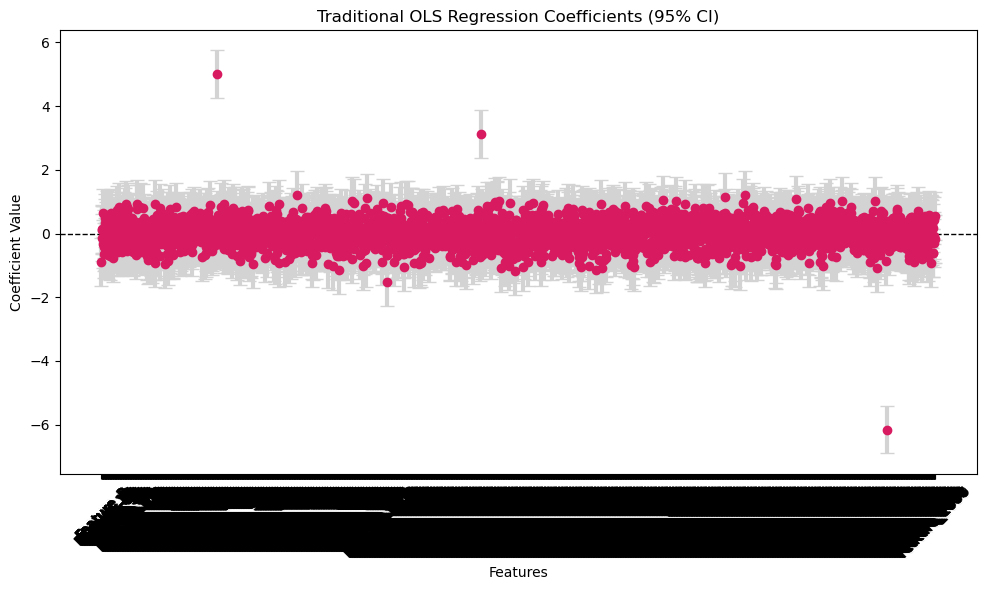

OLS Significant Features: {'Feature_2828': {'pvalue': 7.093805704058778e-58, 'coefficient': -6.154607038888933}, 'Feature_417': {'pvalue': 8.524344576573636e-39, 'coefficient': 4.997428622893771}, 'Feature_1364': {'pvalue': 2.998351598039758e-16, 'coefficient': 3.1253959650180847}}
Execution time: 95.22102761268616 seconds


In [32]:

# 2. Traditional Baseline (OLS)
start_time = time.time()
ols_model, significant_features = perform_traditional_regression(X_train, y_train)
end_time = time.time()

print("OLS Significant Features:", significant_features)
print(f"Execution time: {end_time - start_time} seconds")


#### test Traditional Baseline (OLS) results

In [33]:

print("Testing Traditional Baseline (OLS):")
metrics = evaluate_feature_discovery(significant_features, true_linear_weights, true_interaction_weights)

# print("Testing String Input:")
# metrics2 = evaluate_feature_discovery(list(significant_features.keys()), true_linear_weights, true_interaction_weights)

# metrics

Testing Traditional Baseline (OLS):

           FEATURE DISCOVERY EVALUATION
Total True (Visible) Features: 32
  ├─ Purely Linear / Main:     3
  └─ Involved in Interactions: 29
Total Model Features Found:    3
--------------------------------------------------
True Positives (Correct): 3 -> ['Feature_1364', 'Feature_417', 'Feature_2828']
False Positives (Noise):  0 -> []
False Negatives (Missed): 29 -> ['Feature_352', 'Feature_1386', 'Feature_1571', 'Feature_759', 'Feature_1034', 'Feature_1178', 'Feature_481', 'Feature_340', 'Feature_1350', 'Feature_17', 'Feature_1411', 'Feature_627', 'Feature_534', 'Feature_183', 'Feature_1231', 'Feature_447', 'Feature_2653', 'Feature_2570', 'Feature_2143', 'Feature_612', 'Feature_209', 'Feature_1412', 'Feature_2958', 'Feature_1585', 'Feature_1957', 'Feature_2250', 'Feature_1445', 'Feature_498', 'Feature_2581']
--------------------------------------------------
Precision:            1.0000
Overall Recall:       0.0938
  ├─ Linear Recall:   1.0000  (F

In [34]:
significant_features
ols_model.summary()


coefs = ols_model.params.drop('const')
pvalues = ols_model.pvalues.drop('const')
conf_int = ols_model.conf_int().drop('const')

ols_results_df = pd.DataFrame({
    'feature': coefs.index,
    'coefficient': coefs,
    'p_value': pvalues,
    'ci_lower': conf_int[0],
    'ci_upper': conf_int[1]
})
ols_results_df.sort_values(by='p_value', inplace=True)
ols_results_df.set_index('feature', inplace=True)
ols_results_df


# get a list of the union of the keys of true_linear_weights and true_interaction_weights
all_keys = set(true_linear_weights.keys()) | set(true_interaction_weights.keys())
all_keys

print("Mean OLS coefficient for true contributing features:", ols_results_df[ols_results_df.index.isin(all_keys)]['coefficient'].mean())
print("Mean OLS coefficient for non-contributing features:", ols_results_df[~ols_results_df.index.isin(all_keys)]['coefficient'].mean())

print("Mean OLS p-value for true contributing features:", ols_results_df[ols_results_df.index.isin(all_keys)]['p_value'].mean())
print("Mean OLS p-value for non-contributing features:", ols_results_df[~ols_results_df.index.isin(all_keys)]['p_value'].mean())

ols_results_df[ols_results_df.index.isin(all_keys)].sort_values(by='p_value', ascending=True)


Mean OLS coefficient for true contributing features: 0.07388209580759725
Mean OLS coefficient for non-contributing features: -0.002799745871044267
Mean OLS p-value for true contributing features: 0.4534102149879144
Mean OLS p-value for non-contributing features: 0.4989581788797014


,coefficient,p_value,ci_lower,ci_upper
feature,,,,
Feature_2828,-6.154607,7.093806e-58,-6.905525,-5.403689
Feature_417,4.997429,8.524345e-39,4.246423,5.748434
Feature_1364,3.125396,2.998352e-16,2.376251,3.874541
Feature_759,-0.935220,1.401329e-02,-1.681263,-0.189177
Feature_2581,0.656279,8.562095e-02,-0.092015,1.404573
Feature_627,0.612936,1.068055e-01,-0.131981,1.357853
Feature_481,0.532800,1.644690e-01,-0.218376,1.283975
Feature_2653,0.515116,1.786160e-01,-0.235517,1.265748
Feature_1411,0.494541,1.974016e-01,-0.257441,1.246523


## make a simple xgboost model for test 4

In [35]:

# 3. Machine Learning Modeling (XGBoost)
# We pass the pre-split data directly to ensure apples-to-apples comparison
start_time = time.time()
small_xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, base_score=np.mean(y_train), missing=np.nan, n_jobs=-1)
small_xgb_model.fit(X_train, y_train)

# Evaluate the XGBoost Model on the test set
evaluate_xgb_model(small_xgb_model, X_test, y_test)
end_time = time.time()
print(f"Execution time: {end_time - start_time} seconds")



--- XGBoost Performance (Testing) ---
R-squared Score:                0.0148
Mean Squared Error (MSE):       165976.1427
Root Mean Squared Error (RMSE): 407.4017
Mean Absolute Error (MAE):      326.9432
-------------------------------------

Execution time: 145.2695517539978 seconds


In [36]:

# 3. Machine Learning Modeling (XGBoost)
# We pass the pre-split data directly to ensure apples-to-apples comparison
start_time = time.time()
big_xgb_model = xgb.XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, base_score=np.mean(y_train), missing=np.nan, n_jobs=-1)
big_xgb_model.fit(X_train, y_train)

# Evaluate the XGBoost Model on the test set
evaluate_xgb_model(big_xgb_model, X_test, y_test)
end_time = time.time()
print(f"Execution time: {end_time - start_time} seconds")




--- XGBoost Performance (Testing) ---
R-squared Score:                0.0088
Mean Squared Error (MSE):       166999.8397
Root Mean Squared Error (RMSE): 408.6561
Mean Absolute Error (MAE):      327.3646
-------------------------------------

Execution time: 378.405309677124 seconds


In [37]:

# 3. Machine Learning Modeling (XGBoost)
# We pass the pre-split data directly to ensure apples-to-apples comparison
start_time = time.time()
big_xgb_model_2_W = xgb.XGBRegressor(n_estimators=400, max_depth=5, learning_rate=0.1, base_score=np.mean(y_train), missing=np.nan, n_jobs=-1)
big_xgb_model_2_W.fit(X_train, y_train)

# Evaluate the XGBoost Model on the test set
evaluate_xgb_model(big_xgb_model_2_W, X_test, y_test)
end_time = time.time()
print(f"Execution time: {end_time - start_time} seconds")




--- XGBoost Performance (Testing) ---
R-squared Score:                0.0199
Mean Squared Error (MSE):       165122.3761
Root Mean Squared Error (RMSE): 406.3525
Mean Absolute Error (MAE):      325.1991
-------------------------------------

Execution time: 729.3610134124756 seconds


In [38]:

# 3. Machine Learning Modeling (XGBoost)
# We pass the pre-split data directly to ensure apples-to-apples comparison
start_time = time.time()
big_xgb_model_2_D = xgb.XGBRegressor(n_estimators=200, max_depth=7, learning_rate=0.1, base_score=np.mean(y_train), missing=np.nan, n_jobs=-1)
big_xgb_model_2_D.fit(X_train, y_train)

# Evaluate the XGBoost Model on the test set
evaluate_xgb_model(big_xgb_model_2_D, X_test, y_test)
end_time = time.time()
print(f"Execution time: {end_time - start_time} seconds")




--- XGBoost Performance (Testing) ---
R-squared Score:                -0.0128
Mean Squared Error (MSE):       170636.3575
Root Mean Squared Error (RMSE): 413.0815
Mean Absolute Error (MAE):      331.3473
-------------------------------------

Execution time: 624.0629231929779 seconds


In [39]:


model = big_xgb_model


### look at XGBoost Native Importances

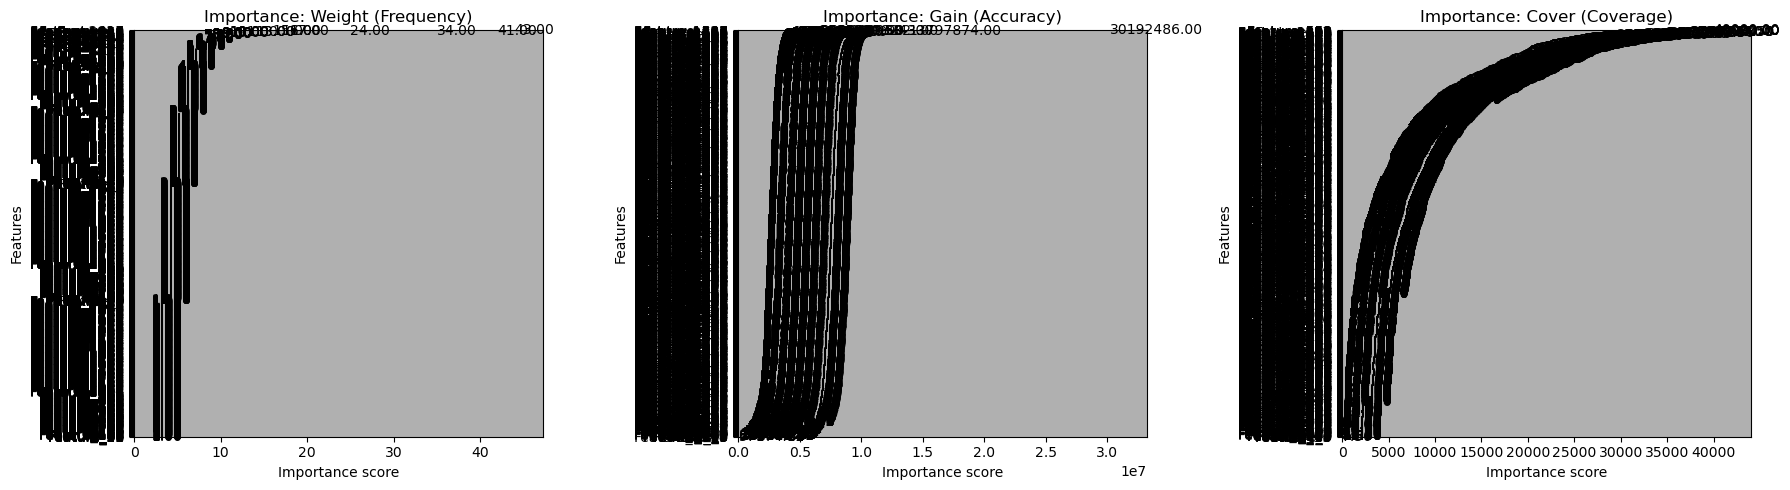

XGBoost Weight Importance: {'Feature_0': 34.0, 'Feature_1': 17.0, 'Feature_2': 13.0, 'Feature_3': 13.0, 'Feature_4': 10.0, 'Feature_5': 10.0, 'Feature_6': 7.0, 'Feature_7': 3.0, 'Feature_8': 3.0, 'Feature_9': 2.0, 'Feature_10': 7.0, 'Feature_11': 10.0, 'Feature_12': 7.0, 'Feature_13': 4.0, 'Feature_14': 4.0, 'Feature_15': 2.0, 'Feature_16': 3.0, 'Feature_17': 3.0, 'Feature_18': 5.0, 'Feature_19': 5.0, 'Feature_20': 2.0, 'Feature_21': 3.0, 'Feature_22': 5.0, 'Feature_23': 4.0, 'Feature_24': 4.0, 'Feature_25': 1.0, 'Feature_26': 2.0, 'Feature_27': 4.0, 'Feature_28': 4.0, 'Feature_29': 2.0, 'Feature_30': 1.0, 'Feature_32': 1.0, 'Feature_33': 3.0, 'Feature_34': 4.0, 'Feature_35': 6.0, 'Feature_36': 3.0, 'Feature_37': 4.0, 'Feature_38': 1.0, 'Feature_40': 3.0, 'Feature_41': 3.0, 'Feature_42': 4.0, 'Feature_43': 3.0, 'Feature_45': 1.0, 'Feature_47': 5.0, 'Feature_48': 3.0, 'Feature_49': 3.0, 'Feature_52': 2.0, 'Feature_53': 3.0, 'Feature_54': 1.0, 'Feature_55': 2.0, 'Feature_56': 2.0, 'Featu

In [40]:

# 4. XGBoost Native Importances
weight_importance, gain_importance, cover_importance = plot_all_xgb_importances(model)

print("XGBoost Weight Importance:", weight_importance)
print("XGBoost Gain Importance:", gain_importance)
print("XGBoost Cover Importance:", cover_importance)


#### test XGBoost Native Importances results

In [41]:

C = 1.0 # Adjust this constant to be more or less strict in filtering features based on standard deviation

significant_features = weight_importance
# get only values above the mean
significant_features = {k: v for k, v in significant_features.items() if v > np.mean(list(significant_features.values())) +C*np.std(list(significant_features.values()))}
significant_features 

print("Testing weight_importance:")
metrics = evaluate_feature_discovery(significant_features, true_linear_weights, true_interaction_weights)

significant_features = gain_importance
# get only values above the mean
significant_features = {k: v for k, v in significant_features.items() if v > np.mean(list(significant_features.values())) +C*np.std(list(significant_features.values()))}
significant_features 

print("Testing gain_importance:")
metrics = evaluate_feature_discovery(significant_features, true_linear_weights, true_interaction_weights)

significant_features = cover_importance
# get only values above the mean
significant_features = {k: v for k, v in significant_features.items() if v > np.mean(list(significant_features.values())) +C*np.std(list(significant_features.values()))}
significant_features 

print("Testing cover_importance:")
metrics = evaluate_feature_discovery(significant_features, true_linear_weights, true_interaction_weights)



Testing weight_importance:

           FEATURE DISCOVERY EVALUATION
Total True (Visible) Features: 32
  ├─ Purely Linear / Main:     3
  └─ Involved in Interactions: 29
Total Model Features Found:    217
--------------------------------------------------
True Positives (Correct): 13 -> ['Feature_2828', 'Feature_1386', 'Feature_759', 'Feature_1957', 'Feature_1411', 'Feature_627', 'Feature_1364', 'Feature_417', 'Feature_183', 'Feature_1445', 'Feature_1231', 'Feature_481', 'Feature_340']
False Positives (Noise):  204 -> ['Feature_1590', 'Feature_1', 'Feature_2112', 'Feature_956', 'Feature_2282', 'Feature_1388', 'Feature_2166', 'Feature_12', 'Feature_798', 'Feature_130', 'Feature_435', 'Feature_796', 'Feature_909', 'Feature_854', 'Feature_1481', 'Feature_1938', 'Feature_2422', 'Feature_1755', 'Feature_735', 'Feature_512', 'Feature_1376', 'Feature_2355', 'Feature_1897', 'Feature_1153', 'Feature_2148', 'Feature_2024', 'Feature_2799', 'Feature_2234', 'Feature_5', 'Feature_1743', 'Feature_2310

In [42]:


# get a list of the union of the keys of true_linear_weights and true_interaction_weights
all_keys = set(true_linear_weights.keys()) | set(true_interaction_weights.keys())
all_keys

print("Mean XGBoost weight importance for true contributing features:", np.mean([weight_importance.get(k, 0) for k in all_keys]))
print("Mean XGBoost weight importance for non-contributing features:", np.mean([weight_importance.get(k, 0) for k in weight_importance if k not in all_keys]))

print("STD XGBoost weight importance for all features:", np.std([weight_importance.get(k, 0) for k in weight_importance]))

# Get the weight importances for all keys
weight_importances_for_all_keys = {k: weight_importance.get(k, 0) for k in all_keys}
# Sort by importance
sorted_weight_importances = dict(sorted(weight_importances_for_all_keys.items(), key=lambda item: item[1], reverse=True))
print("XGBoost weight importance for all contributing features (sorted):")
sorted_weight_importances



Mean XGBoost weight importance for true contributing features: 6.27027027027027
Mean XGBoost weight importance for non-contributing features: 2.4004065040650406
STD XGBoost weight importance for all features: 2.0788802516098075
XGBoost weight importance for all contributing features (sorted):


{'Feature_2828': 43.0,
 'Feature_417': 41.0,
 'Feature_1364': 24.0,
 'Feature_1445': 16.0,
 'Feature_759': 15.0,
 'Feature_1386': 9.0,
 'Feature_340': 7.0,
 'Feature_1231': 7.0,
 'Feature_627': 6.0,
 'Feature_481': 5.0,
 'Feature_1411': 5.0,
 'Feature_183': 5.0,
 'Feature_1957': 5.0,
 'Feature_612': 4.0,
 'Feature_352': 3.0,
 'Feature_1571': 3.0,
 'Feature_1178': 3.0,
 'Feature_17': 3.0,
 'Feature_2653': 3.0,
 'Feature_2143': 3.0,
 'Feature_1585': 3.0,
 'Feature_2581': 3.0,
 'Feature_1034': 2.0,
 'Feature_447': 2.0,
 'Feature_2570': 2.0,
 'Feature_209': 2.0,
 'Feature_2958': 2.0,
 'Feature_2250': 2.0,
 'Feature_498': 2.0,
 'Feature_1350': 1.0,
 'Feature_534': 1.0,
 'Hidden_178': 0,
 'Feature_1412': 0,
 'Hidden_35': 0,
 'Hidden_52': 0,
 'Hidden_153': 0,
 'Hidden_8': 0}

In [43]:


# get a list of the union of the keys of true_linear_weights and true_interaction_weights
all_keys = set(true_linear_weights.keys()) | set(true_interaction_weights.keys())
all_keys

print("Mean XGBoost gain importance for true contributing features:", np.mean([gain_importance.get(k, 0) for k in all_keys]))
print("Mean XGBoost gain importance for non-contributing features:", np.mean([gain_importance.get(k, 0) for k in gain_importance if k not in all_keys]))

print("STD of XGBoost gain importance for all features:", np.std(list(gain_importance.values())))

# Get the gain importances for all keys
gain_importances_for_all_keys = {k: gain_importance.get(k, 0) for k in all_keys}
# Sort by importance
sorted_gain_importances = dict(sorted(gain_importances_for_all_keys.items(), key=lambda item: item[1], reverse=True))
print("XGBoost gain importance for all contributing features (sorted):")
sorted_gain_importances



Mean XGBoost gain importance for true contributing features: 3960723.409522804
Mean XGBoost gain importance for non-contributing features: 2294428.4802210364
STD of XGBoost gain importance for all features: 897762.4355323187
XGBoost gain importance for all contributing features (sorted):


{'Feature_1585': 30192486.0,
 'Feature_1445': 13797874.0,
 'Feature_627': 9418243.0,
 'Feature_759': 9009332.0,
 'Feature_1386': 6682182.0,
 'Feature_2828': 6565380.5,
 'Feature_481': 6480830.5,
 'Feature_417': 4960162.5,
 'Feature_340': 4198577.5,
 'Feature_183': 3737958.5,
 'Feature_534': 3516575.0,
 'Feature_1364': 3506992.75,
 'Feature_1231': 3320970.75,
 'Feature_1350': 3235675.5,
 'Feature_1957': 3137892.5,
 'Feature_1571': 3047013.25,
 'Feature_2958': 3021045.5,
 'Feature_352': 2939252.75,
 'Feature_2250': 2937970.25,
 'Feature_1411': 2582827.75,
 'Feature_1178': 2481933.25,
 'Feature_2570': 2392706.5,
 'Feature_2653': 2218609.25,
 'Feature_2581': 2128278.0,
 'Feature_447': 2100288.5,
 'Feature_2143': 2075041.625,
 'Feature_612': 2074480.875,
 'Feature_1034': 2042645.5,
 'Feature_498': 1372745.0,
 'Feature_209': 1311216.875,
 'Feature_17': 59578.27734375,
 'Hidden_178': 0,
 'Feature_1412': 0,
 'Hidden_35': 0,
 'Hidden_52': 0,
 'Hidden_153': 0,
 'Hidden_8': 0}

In [44]:


# get a list of the union of the keys of true_linear_weights and true_interaction_weights
all_keys = set(true_linear_weights.keys()) | set(true_interaction_weights.keys())
all_keys

print("Mean XGBoost cover importance for true contributing features:", np.mean([cover_importance.get(k, 0) for k in all_keys]))
print("Mean XGBoost cover importance for non-contributing features:", np.mean([cover_importance.get(k, 0) for k in cover_importance if k not in all_keys]))

print("STD XGBoost cover importance for all features:", np.std([cover_importance.get(k, 0) for k in cover_importance]))

# Get the cover importances for all keys
cover_importances_for_all_keys = {k: cover_importance.get(k, 0) for k in all_keys}
# Sort by importance
sorted_cover_importances = dict(sorted(cover_importances_for_all_keys.items(), key=lambda item: item[1], reverse=True))
print("XGBoost cover importance for all contributing features (sorted):")
sorted_cover_importances



Mean XGBoost cover importance for true contributing features: 5442.392467318355
Mean XGBoost cover importance for non-contributing features: 5185.631286479594
STD XGBoost cover importance for all features: 7069.790438873511
XGBoost cover importance for all contributing features (sorted):


{'Feature_2828': 25993.0234375,
 'Feature_417': 22269.78125,
 'Feature_1364': 20570.333984375,
 'Feature_447': 16479.0,
 'Feature_1585': 14842.6669921875,
 'Feature_627': 13418.0,
 'Feature_481': 12954.0,
 'Feature_612': 11063.25,
 'Feature_759': 10572.466796875,
 'Feature_1386': 7108.66650390625,
 'Feature_352': 6775.33349609375,
 'Feature_1411': 5962.7998046875,
 'Feature_1445': 5880.9375,
 'Feature_2653': 4349.66650390625,
 'Feature_2958': 4180.5,
 'Feature_1957': 3189.199951171875,
 'Feature_1571': 2294.333251953125,
 'Feature_2143': 2055.333251953125,
 'Feature_2570': 1942.5,
 'Feature_1231': 1765.5714111328125,
 'Feature_340': 1496.857177734375,
 'Feature_1034': 1375.0,
 'Feature_1178': 1335.0,
 'Feature_2250': 1328.5,
 'Feature_534': 821.0,
 'Feature_183': 463.79998779296875,
 'Feature_2581': 422.6666564941406,
 'Feature_1350': 350.0,
 'Feature_498': 51.5,
 'Feature_209': 48.5,
 'Feature_17': 8.333333015441895,
 'Hidden_178': 0,
 'Feature_1412': 0,
 'Hidden_35': 0,
 'Hidden_52':

### try to use SHAP to find the influencing inputs

In [45]:

# 5. Explainability (SHAP)
start_time = time.time()
shap_values = compute_shap_values(model, X_train, X_test)
end_time = time.time()
print(f"Execution time: {end_time - start_time} seconds")


Execution time: 4.115252256393433 seconds


#### individual SHAP features ranking

Plotting SHAP analysis for top 5 features: ['Feature_2828', 'Feature_417', 'Feature_1364', 'Feature_759', 'Feature_1445']


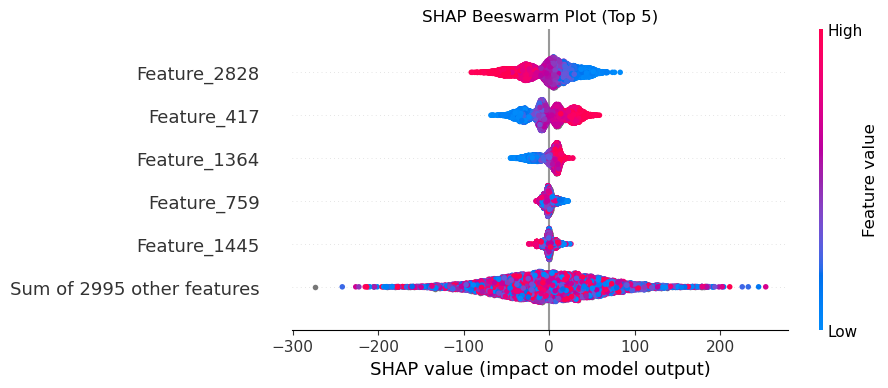

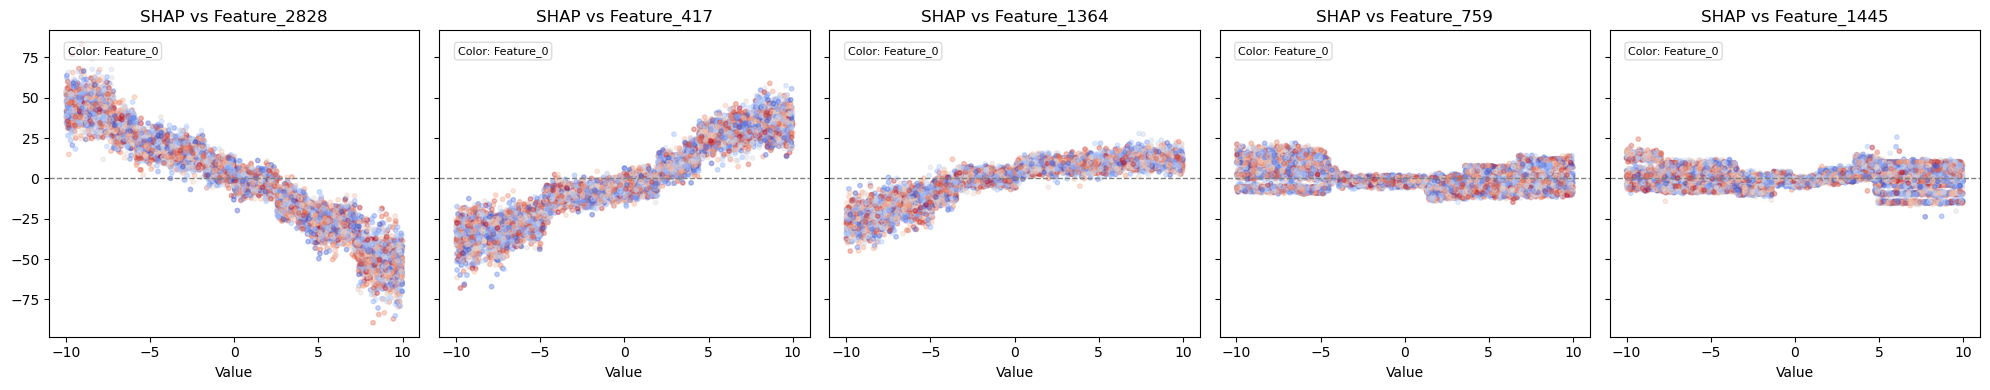

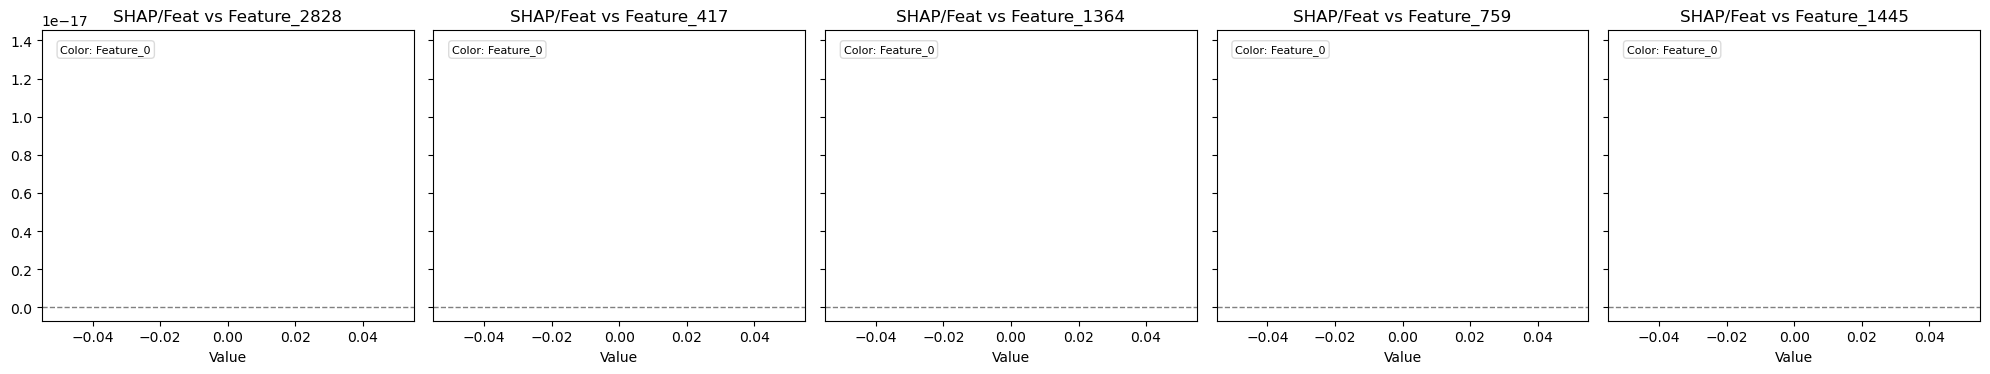

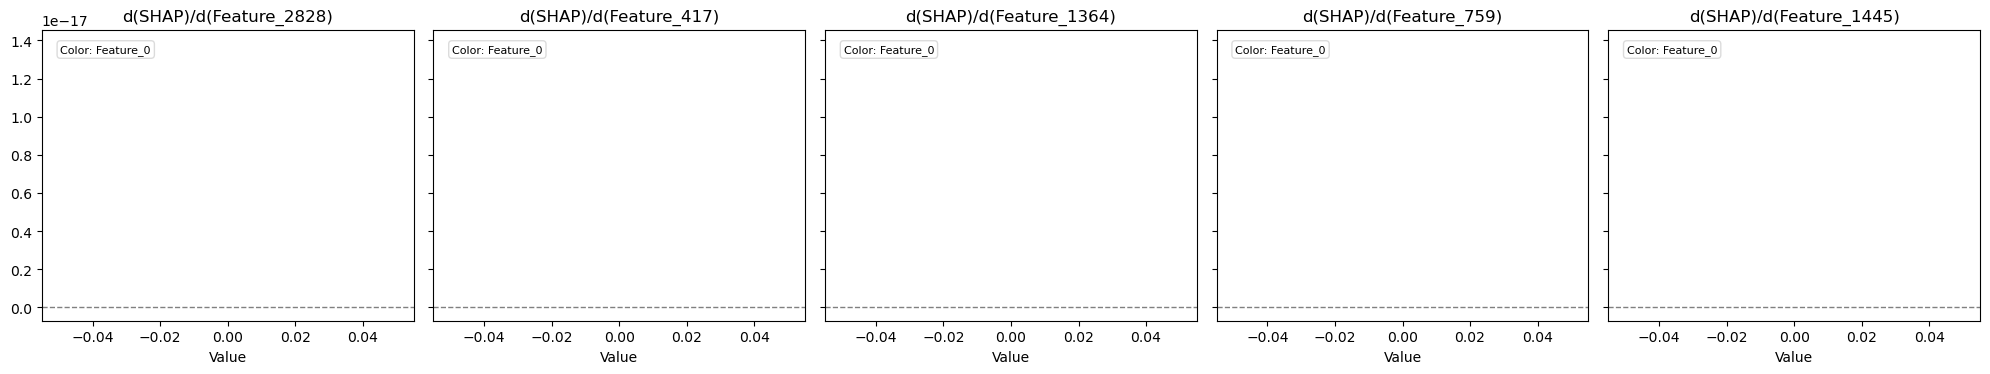

In [46]:

# 6. Visualization (SHAP)
plot_shap_analysis(shap_values, feature_names)


#### SHAP summry

In [47]:

# 8. Summary (SHAP)
ranked_features = print_feature_importance(shap_values)

print("Ranked Features by SHAP Importance:", ranked_features)



--- SHAP Feature Importance Ranking ---
SHAP Global Importance Dictionary:
  Feature_2828: 23.4284
  Feature_417: 19.7962
  Feature_1364: 10.3175
  Feature_759: 4.5816
  Feature_1445: 4.1405
  Feature_1026: 3.9952
  Feature_2315: 3.3564
  Feature_2245: 3.0997
  Feature_854: 2.8841
  Feature_816: 2.8198
  Feature_902: 2.7672
  Feature_2101: 2.7204
  Feature_956: 2.4737
  Feature_2596: 2.3595
  Feature_1585: 2.3389
  Feature_1369: 2.3368
  Feature_1488: 2.3007
  Feature_1432: 2.2863
  Feature_1907: 2.2447
  Feature_227: 2.2258
  Feature_1987: 2.2052
  Feature_2764: 2.2008
  Feature_627: 2.1595
  Feature_1755: 2.1493
  Feature_481: 2.1457
  Feature_1535: 2.1373
  Feature_403: 2.1328
  Feature_496: 2.1192
  Feature_1467: 2.0813
  Feature_1392: 2.0585
  Feature_2470: 2.0500
  Feature_1386: 2.0409
  Feature_1324: 2.0059
  Feature_1470: 1.9911
  Feature_2170: 1.9705
  Feature_1554: 1.9699
  Feature_2222: 1.9415
  Feature_1088: 1.9201
  Feature_894: 1.8970
  Feature_834: 1.8852
  Feature_2067

#### test SHAP Importances results

In [48]:
C = 1.0 # Adjust this constant to be more or less strict in filtering features based on standard deviation

significant_features = ranked_features
# get only values above the mean
significant_features = {k: v for k, v in significant_features.items() if v > np.mean(list(significant_features.values())) +C*np.std(list(significant_features.values()))}
significant_features 

print("Testing SHAP importance:")
metrics = evaluate_feature_discovery(significant_features, true_linear_weights, true_interaction_weights)



Testing SHAP importance:

           FEATURE DISCOVERY EVALUATION
Total True (Visible) Features: 32
  ├─ Purely Linear / Main:     3
  └─ Involved in Interactions: 29
Total Model Features Found:    160
--------------------------------------------------
True Positives (Correct): 9 -> ['Feature_2828', 'Feature_1386', 'Feature_759', 'Feature_1585', 'Feature_627', 'Feature_1364', 'Feature_417', 'Feature_1445', 'Feature_481']
False Positives (Noise):  151 -> ['Feature_1590', 'Feature_1123', 'Feature_227', 'Feature_1137', 'Feature_956', 'Feature_2282', 'Feature_2956', 'Feature_1388', 'Feature_2985', 'Feature_1963', 'Feature_2406', 'Feature_435', 'Feature_2823', 'Feature_2425', 'Feature_2422', 'Feature_854', 'Feature_1755', 'Feature_1897', 'Feature_2024', 'Feature_1987', 'Feature_2310', 'Feature_1275', 'Feature_1780', 'Feature_1886', 'Feature_1010', 'Feature_1676', 'Feature_389', 'Feature_2483', 'Feature_894', 'Feature_1643', 'Feature_2428', 'Feature_2790', 'Feature_1371', 'Feature_580', 'Fea

In [49]:


# get a list of the union of the keys of true_linear_weights and true_interaction_weights
all_keys = set(true_linear_weights.keys()) | set(true_interaction_weights.keys())
all_keys

print("Mean XGBoost SHAP importance for true contributing features:", np.mean([ranked_features.get(k, 0) for k in all_keys]))
print("Mean XGBoost SHAP importance for non-contributing features:", np.mean([ranked_features.get(k, 0) for k in ranked_features if k not in all_keys]))

print("STD XGBoost SHAP importance for all features:", np.std([ranked_features.get(k, 0) for k in ranked_features]))

# Get the SHAP importances for all keys
shap_importances_for_all_keys = {k: ranked_features.get(k, 0) for k in all_keys}
# Sort by importance
sorted_shap_importances = dict(sorted(shap_importances_for_all_keys.items(), key=lambda item: item[1], reverse=True))
print("XGBoost SHAP importance for all contributing features (sorted):")
sorted_shap_importances



Mean XGBoost SHAP importance for true contributing features: 2.0899438889118263
Mean XGBoost SHAP importance for non-contributing features: 0.27565965
STD XGBoost SHAP importance for all features: 0.7045128
XGBoost SHAP importance for all contributing features (sorted):


{'Feature_2828': 23.428406,
 'Feature_417': 19.796228,
 'Feature_1364': 10.3175125,
 'Feature_759': 4.581641,
 'Feature_1445': 4.1404657,
 'Feature_1585': 2.3389413,
 'Feature_627': 2.1595118,
 'Feature_481': 2.1456585,
 'Feature_1386': 2.0409179,
 'Feature_1411': 0.8158898,
 'Feature_612': 0.7327345,
 'Feature_352': 0.5722002,
 'Feature_340': 0.46773773,
 'Feature_447': 0.45307308,
 'Feature_1957': 0.37690115,
 'Feature_2653': 0.3641759,
 'Feature_183': 0.33851144,
 'Feature_1231': 0.2974247,
 'Feature_1571': 0.287617,
 'Feature_2958': 0.2838054,
 'Feature_1178': 0.27494803,
 'Feature_2570': 0.23448132,
 'Feature_2250': 0.2326269,
 'Feature_1034': 0.16191067,
 'Feature_2143': 0.13276398,
 'Feature_534': 0.12992412,
 'Feature_2581': 0.10721642,
 'Feature_1350': 0.05307201,
 'Feature_209': 0.0287642,
 'Feature_498': 0.028120391,
 'Feature_17': 0.0047418806,
 'Hidden_178': 0,
 'Feature_1412': 0.0,
 'Hidden_35': 0,
 'Hidden_52': 0,
 'Hidden_153': 0,
 'Hidden_8': 0}

## try SAGE (Shapley Additive Global importancE) importance

In [50]:

import sage
import pandas as pd
import numpy as np

def compute_sage_importance(model, X_train, X_test, y_test, feature_names):
    """
    Computes global feature importance using SAGE.
    Measures the exact reduction in Mean Squared Error (MSE) each feature contributes.
    """
    print("\n[SAGE] Computing global loss-reduction values...")
    
    # 1. Set up a marginal imputer using a background sample from X_train.
    bg_sample = X_train.head(512).values if isinstance(X_train, pd.DataFrame) else X_train[:512]
    imputer = sage.MarginalImputer(model, bg_sample)
    
    # 2. Set up the estimator using 'mse' to match continuous regression targets
    estimator = sage.PermutationEstimator(imputer, 'mse')
    
    # 3. FIX: Convert BOTH X and y to numpy arrays to prevent pandas indexing mismatches
    X_test_arr = X_test.values if isinstance(X_test, pd.DataFrame) else X_test
    y_test_arr = y_test.values if isinstance(y_test, pd.Series) else y_test
    
    # Calculate SAGE values
    sage_values = estimator(X_test_arr, y_test_arr,
                            n_permutations=10,         # Hard-cap the number of permutations
                            detect_convergence=False,  # Prevent it from looping until convergence
                            verbose=True)
    
    # 4. Map values to feature names and sort
    sage_ranked = dict(zip(feature_names, sage_values.values))
    sage_ranked = {k: v for k, v in sorted(sage_ranked.items(), key=lambda item: item[1], reverse=True)}
    
    return sage_ranked, sage_values


In [51]:
# ## to slow to be affective/work

# # sage_ranked, sage_values = compute_sage_importance(model, X_train, X_test, y_test, feature_names)

# # sage_ranked, sage_values

# # ==========================================
# # 11. SAGE GLOBAL IMPORTANCE ANALYSIS
# # ==========================================

# N = 100  # Number of samples to use for SAGE calculation (adjust as needed)

# sage_ranked, sage_values_obj = compute_sage_importance(
#     model=model,
#     X_train=X_train.iloc[:N, :],
#     X_test=X_test.iloc[:N, :],
#     y_test=y_test.iloc[:N],
#     feature_names=feature_names
# )

# # In SAGE, any feature with an importance > 0 actively reduces the model's error.
# # Features <= 0 are redundant or pure noise.
# significant_features_sage = {k: v for k, v in sage_ranked.items() if v > 0}

# print("\nTesting SAGE importance discovery:")
# metrics_sage = evaluate_feature_discovery(
#     significant_features_sage, 
#     true_linear_weights, 
#     true_interaction_weights
# )

# # Optional: You can also use the built-in plotting tool
# sage_values_obj.plot(feature_names)



## make simple CatBoost model

In [52]:
# Ensure catboost is installed: !pip install catboost
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def evaluate_catboost_model(model, X_test, y_test):
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    
    print("\n--- CatBoost Performance (Testing) ---")
    print(f"R-squared Score: {r2:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print("-------------------------------------")

In [53]:
# 3b. Machine Learning Modeling (CatBoost)
start_time = time.time()

# CatBoost parameters mapping:
# n_estimators -> iterations
# max_depth -> depth
# n_jobs -> thread_count
big_cat_model = CatBoostRegressor(
    iterations=200, 
    depth=5, 
    learning_rate=0.1, 
    thread_count=-1, 
    verbose=50 # Prints training loss every 50 iterations (set to False to turn off)
)

big_cat_model.fit(X_train, y_train)

# Evaluate on the pre-split test set
evaluate_catboost_model(big_cat_model, X_test, y_test)

end_time = time.time()
print(f"Execution time: {end_time - start_time} seconds")

0:	learn: 405.9689887	total: 475ms	remaining: 1m 34s
50:	learn: 400.7623772	total: 17.1s	remaining: 49.9s
100:	learn: 394.8509381	total: 37.5s	remaining: 36.8s
150:	learn: 388.2700273	total: 54.5s	remaining: 17.7s
199:	learn: 380.5328566	total: 1m 11s	remaining: 0us

--- CatBoost Performance (Testing) ---
R-squared Score: 0.0330
Mean Squared Error (MSE): 162915.6838
Root Mean Squared Error (RMSE): 403.6282
Mean Absolute Error (MAE): 324.0304
-------------------------------------
Execution time: 74.3641791343689 seconds


In [54]:

# Variant 1: More estimators / iterations (matching big_model_2_W)
start_time = time.time()
cat_model_2_W = CatBoostRegressor(iterations=400, depth=5, learning_rate=0.1, thread_count=-1, verbose=100)
cat_model_2_W.fit(X_train, y_train)
evaluate_catboost_model(cat_model_2_W, X_test, y_test)
print(f"Execution time: {time.time() - start_time} seconds")



0:	learn: 405.9689887	total: 366ms	remaining: 2m 25s
100:	learn: 394.8509381	total: 37.1s	remaining: 1m 49s
200:	learn: 380.4588358	total: 1m 10s	remaining: 1m 9s
300:	learn: 367.0108960	total: 1m 41s	remaining: 33.4s
399:	learn: 352.6602178	total: 2m 14s	remaining: 0us

--- CatBoost Performance (Testing) ---
R-squared Score: 0.0528
Mean Squared Error (MSE): 159574.1914
Root Mean Squared Error (RMSE): 399.4674
Mean Absolute Error (MAE): 320.6383
-------------------------------------
Execution time: 138.30273604393005 seconds


In [55]:

# Variant 2: Deeper trees (matching big_model_2_D)
start_time = time.time()
cat_model_2_D = CatBoostRegressor(iterations=200, depth=7, learning_rate=0.1, thread_count=-1, verbose=50)
cat_model_2_D.fit(X_train, y_train)
evaluate_catboost_model(cat_model_2_D, X_test, y_test)
print(f"Execution time: {time.time() - start_time} seconds")


0:	learn: 405.8756563	total: 1.03s	remaining: 3m 24s
50:	learn: 395.1004961	total: 42.8s	remaining: 2m 4s
100:	learn: 381.2686964	total: 1m 23s	remaining: 1m 21s
150:	learn: 367.7878241	total: 2m 2s	remaining: 39.9s
199:	learn: 351.5373958	total: 2m 45s	remaining: 0us

--- CatBoost Performance (Testing) ---
R-squared Score: 0.0825
Mean Squared Error (MSE): 154576.1644
Root Mean Squared Error (RMSE): 393.1618
Mean Absolute Error (MAE): 315.5484
-------------------------------------
Execution time: 169.6532826423645 seconds


## make simple LightGBM model

In [56]:
# Ensure lightgbm is installed: !pip install lightgbm
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def evaluate_lgbm_model(model, X_test, y_test):
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    
    print("\n--- LightGBM Performance (Testing) ---")
    print(f"R-squared Score: {r2:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print("-------------------------------------")

In [57]:
# 3c. Machine Learning Modeling (LightGBM)
start_time = time.time()

big_lgbm_model = LGBMRegressor(
    n_estimators=200, 
    max_depth=5, 
    num_leaves=31, 
    learning_rate=0.1, 
    n_jobs=-1,
    random_state=42
)

big_lgbm_model.fit(X_train, y_train)

# Evaluate on the pre-split test set
evaluate_lgbm_model(big_lgbm_model, X_test, y_test)

end_time = time.time()
print(f"Execution time: {end_time - start_time} seconds")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.629053 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765000
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 3000
[LightGBM] [Info] Start training from score -0.452165
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

In [58]:


# Variant 1: More estimators (matching big_model_2_W)
start_time = time.time()
lgbm_model_2_W = LGBMRegressor(n_estimators=400, max_depth=5, num_leaves=31, learning_rate=0.1, n_jobs=-1, random_state=42)
lgbm_model_2_W.fit(X_train, y_train)
evaluate_lgbm_model(lgbm_model_2_W, X_test, y_test)
print(f"Execution time: {time.time() - start_time} seconds")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.409782 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765000
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 3000
[LightGBM] [Info] Start training from score -0.452165
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

In [59]:

# Variant 2: Deeper trees (matching big_model_2_D)
start_time = time.time()
# Adjusted num_leaves up to 63 to allow deeper trees (2^7 is max 128, 63 is standard for depth 7)
lgbm_model_2_D = LGBMRegressor(n_estimators=200, max_depth=7, num_leaves=63, learning_rate=0.1, n_jobs=-1, random_state=42)
lgbm_model_2_D.fit(X_train, y_train)
evaluate_lgbm_model(lgbm_model_2_D, X_test, y_test)
print(f"Execution time: {time.time() - start_time} seconds")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.409261 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765000
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 3000
[LightGBM] [Info] Start training from score -0.452165
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

## make simple Random Forest model

In [60]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import time

def evaluate_rf_model(model, X_test, y_test):
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    
    print("\n--- Random Forest Performance (Testing) ---")
    print(f"R-squared Score: {r2:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print("-----------------------------------------")

In [61]:

# 3d. Machine Learning Modeling (Random Forest)
start_time = time.time()

small_rf_model = RandomForestRegressor(
    n_estimators=100, 
    max_depth=3, 
    n_jobs=-1,
    random_state=42
)

small_rf_model.fit(X_train, y_train)

# Evaluate on the pre-split test set
evaluate_rf_model(small_rf_model, X_test, y_test)

end_time = time.time()
print(f"Execution time: {end_time - start_time} seconds")




--- Random Forest Performance (Testing) ---
R-squared Score: 0.0097
Mean Squared Error (MSE): 166840.7303
Root Mean Squared Error (RMSE): 408.4614
Mean Absolute Error (MAE): 327.8297
-----------------------------------------
Execution time: 1023.1376144886017 seconds


In [62]:

# # take very long to run

# # 3d. Machine Learning Modeling (Random Forest)
# start_time = time.time()

# big_rf_model = RandomForestRegressor(
#     n_estimators=200, 
#     max_depth=5, 
#     n_jobs=-1,
#     random_state=42
# )

# big_rf_model.fit(X_train, y_train)

# # Evaluate on the pre-split test set
# evaluate_rf_model(big_rf_model, X_test, y_test)

# end_time = time.time()
# print(f"Execution time: {end_time - start_time} seconds")



In [63]:

# # take to long to run

# # Variant 1: More estimators (matching big_model_2_W)
# start_time = time.time()
# rf_model_2_W = RandomForestRegressor(n_estimators=400, max_depth=5, n_jobs=-1, random_state=42)
# rf_model_2_W.fit(X_train, y_train)
# evaluate_rf_model(rf_model_2_W, X_test, y_test)
# print(f"Execution time: {time.time() - start_time} seconds")


In [64]:


# # take to long to run

# # Variant 2: Deeper trees (matching big_model_2_D)
# start_time = time.time()
# rf_model_2_D = RandomForestRegressor(n_estimators=200, max_depth=7, n_jobs=-1, random_state=42)
# rf_model_2_D.fit(X_train, y_train)
# evaluate_rf_model(rf_model_2_D, X_test, y_test)
# print(f"Execution time: {time.time() - start_time} seconds")


## make simple Extremely Randomized Trees model

In [65]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import time

def evaluate_et_model(model, X_test, y_test):
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    
    print("\n--- Extra Trees Performance (Testing) ---")
    print(f"R-squared Score: {r2:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print("-----------------------------------------")

# Baseline Model (Matching big_model)
start_time = time.time()
big_et_model = ExtraTreesRegressor(n_estimators=200, max_depth=5, n_jobs=-1, random_state=42)
big_et_model.fit(X_train, y_train)
evaluate_et_model(big_et_model, X_test, y_test)
print(f"Execution time: {time.time() - start_time} seconds")



--- Extra Trees Performance (Testing) ---
R-squared Score: 0.0105
Mean Squared Error (MSE): 166710.5683
Root Mean Squared Error (RMSE): 408.3021
Mean Absolute Error (MAE): 327.6661
-----------------------------------------
Execution time: 321.42656230926514 seconds


In [66]:

# Variant 1: More estimators (Matching big_model_2_W)
start_time = time.time()
et_model_2_W = ExtraTreesRegressor(n_estimators=400, max_depth=5, n_jobs=-1, random_state=42)
et_model_2_W.fit(X_train, y_train)
evaluate_et_model(et_model_2_W, X_test, y_test)
print(f"Execution time: {time.time() - start_time} seconds")



--- Extra Trees Performance (Testing) ---
R-squared Score: 0.0104
Mean Squared Error (MSE): 166716.8186
Root Mean Squared Error (RMSE): 408.3097
Mean Absolute Error (MAE): 327.6773
-----------------------------------------
Execution time: 643.4135818481445 seconds


In [67]:

# Variant 2: Deeper trees (Matching big_model_2_D)
start_time = time.time()
et_model_2_D = ExtraTreesRegressor(n_estimators=200, max_depth=7, n_jobs=-1, random_state=42)
et_model_2_D.fit(X_train, y_train)
evaluate_et_model(et_model_2_D, X_test, y_test)
print(f"Execution time: {time.time() - start_time} seconds")


--- Extra Trees Performance (Testing) ---
R-squared Score: 0.0110
Mean Squared Error (MSE): 166628.9808
Root Mean Squared Error (RMSE): 408.2021
Mean Absolute Error (MAE): 327.6532
-----------------------------------------
Execution time: 534.7089066505432 seconds


## make simple AdaBoost model

In [68]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import time

def evaluate_ada_model(model, X_test, y_test):
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    
    print("\n--- AdaBoost Performance (Testing) ---")
    print(f"R-squared Score: {r2:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print("--------------------------------------")


In [69]:

# # Baseline Model (Matching big_model)
# start_time = time.time()
# big_ada_model = AdaBoostRegressor(
#     estimator=DecisionTreeRegressor(max_depth=5),
#     n_estimators=200, 
#     learning_rate=0.1,
#     random_state=42
# )
# big_ada_model.fit(X_train, y_train)
# evaluate_ada_model(big_ada_model, X_test, y_test)
# print(f"Execution time: {time.time() - start_time} seconds")


In [70]:

# # Variant 1: More estimators (Matching big_model_2_W)
# start_time = time.time()
# ada_model_2_W = AdaBoostRegressor(
#     estimator=DecisionTreeRegressor(max_depth=5),
#     n_estimators=400, 
#     learning_rate=0.1,
#     random_state=42
# )
# ada_model_2_W.fit(X_train, y_train)
# evaluate_ada_model(ada_model_2_W, X_test, y_test)
# print(f"Execution time: {time.time() - start_time} seconds")


In [71]:

# # Variant 2: Deeper trees (Matching big_model_2_D)
# start_time = time.time()
# ada_model_2_D = AdaBoostRegressor(
#     estimator=DecisionTreeRegressor(max_depth=7),
#     n_estimators=200, 
#     learning_rate=0.1,
#     random_state=42
# )
# ada_model_2_D.fit(X_train, y_train)
# evaluate_ada_model(ada_model_2_D, X_test, y_test)
# print(f"Execution time: {time.time() - start_time} seconds")

## make simple HistGradientBoosting model 

In [72]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import time

def evaluate_hgb_model(model, X_test, y_test):
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    
    print("\n--- HistGradientBoosting Performance (Testing) ---")
    print(f"R-squared Score: {r2:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print("-------------------------------------------------")

In [73]:

# 3e. Machine Learning Modeling (HistGradientBoosting)
start_time = time.time()

# Note: max_iter is used instead of n_estimators
big_hgb_model = HistGradientBoostingRegressor(
    max_iter=200, 
    max_depth=5, 
    learning_rate=0.1,
    random_state=42
)

big_hgb_model.fit(X_train, y_train)

# Evaluate on the original pre-split test set (with NaNs)
evaluate_hgb_model(big_hgb_model, X_test, y_test)

end_time = time.time()
print(f"Execution time: {end_time - start_time} seconds")



--- HistGradientBoosting Performance (Testing) ---
R-squared Score: 0.0066
Mean Squared Error (MSE): 167363.2266
Root Mean Squared Error (RMSE): 409.1005
Mean Absolute Error (MAE): 328.4102
-------------------------------------------------
Execution time: 28.57219171524048 seconds


In [74]:

# Variant 1: More iterations (matching big_model_2_W)
start_time = time.time()
hgb_model_2_W = HistGradientBoostingRegressor(max_iter=400, max_depth=5, learning_rate=0.1, random_state=42)
hgb_model_2_W.fit(X_train, y_train)
evaluate_hgb_model(hgb_model_2_W, X_test, y_test)
print(f"Execution time: {time.time() - start_time} seconds")



--- HistGradientBoosting Performance (Testing) ---
R-squared Score: 0.0066
Mean Squared Error (MSE): 167363.2266
Root Mean Squared Error (RMSE): 409.1005
Mean Absolute Error (MAE): 328.4102
-------------------------------------------------
Execution time: 22.475557804107666 seconds


In [75]:

# Variant 2: Deeper trees (matching big_model_2_D)
start_time = time.time()
hgb_model_2_D = HistGradientBoostingRegressor(max_iter=200, max_depth=7, learning_rate=0.1, random_state=42)
hgb_model_2_D.fit(X_train, y_train)
evaluate_hgb_model(hgb_model_2_D, X_test, y_test)
print(f"Execution time: {time.time() - start_time} seconds")



--- HistGradientBoosting Performance (Testing) ---
R-squared Score: 0.0050
Mean Squared Error (MSE): 167634.6062
Root Mean Squared Error (RMSE): 409.4321
Mean Absolute Error (MAE): 328.6687
-------------------------------------------------
Execution time: 27.62822413444519 seconds


## show Importances

In [76]:
model = big_lgbm_model  # or big_lgbm_model, big_rf_model, etc., depending on which model you want to analyze

### native model Importances

In [77]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_model_importances(model, feature_names=None, max_features=None) -> dict:
    """
    Dynamically extracts, sorts, and plots native feature importances across different 
    model architectures (XGBoost, LightGBM, CatBoost, Random Forest, Extra Trees).
    
    Parameters:
    -----------
    model : trained model object
    feature_names : list of str, optional
        The feature names. If None, attempts to extract them from the model.
    max_features : int, optional
        The maximum number of top features to plot and return. If None, plots all.
        
    Returns:
    --------
    dict : A dictionary of dictionaries containing the top sorted features 
           in descending order of importance.
    """
    model_type = type(model).__name__
    raw_importances = {}  # Holds unsorted data initially
    
    # Attempt to resolve feature names dynamically if not explicitly provided
    if feature_names is None:
        if hasattr(model, 'feature_names_in_'):
            feature_names = list(model.feature_names_in_)
        elif hasattr(model, 'feature_name_'):
            feature_names = model.feature_name_  # LightGBM style
        elif hasattr(model, 'feature_names_'):
            feature_names = model.feature_names_ # CatBoost style
        else:
            print(f"Warning: Could not automatically detect feature names for {model_type}.")
            return {}

    # 1. HANDLING XGBOOST
    if "XGB" in model_type:
        booster = model.get_booster()
        for imp_type in ['weight', 'gain', 'cover']:
            score_dict = booster.get_score(importance_type=imp_type)
            scores = [score_dict.get(f, score_dict.get(f"f{i}", 0)) for i, f in enumerate(feature_names)]
            raw_importances[f"{imp_type.capitalize()} (XGB)"] = pd.Series(scores, index=feature_names)

    # 2. HANDLING LIGHTGBM
    elif "LGBM" in model_type:
        for imp_type in ['split', 'gain']:
            scores = model.booster_.feature_importance(importance_type=imp_type)
            raw_importances[f"{imp_type.capitalize()} (LGBM)"] = pd.Series(scores, index=feature_names)

    # 3. HANDLING CATBOOST
    elif "CatBoost" in model_type:
        scores = model.get_feature_importance()
        raw_importances["PredictionValuesChange (CatBoost)"] = pd.Series(scores, index=feature_names)

    # 4. HANDLING RANDOM FOREST / EXTRA TREES
    elif "RandomForest" in model_type or "ExtraTrees" in model_type:
        scores = model.feature_importances_
        raw_importances["Mean Decrease in Impurity (MDI)"] = pd.Series(scores, index=feature_names)

    # 5. HANDLING HIST GRADIENT BOOSTING
    elif "HistGradientBoosting" in model_type:
        print("\n[Notice] HistGradientBoostingRegressor does not natively expose built-in tree importances.")
        print("Please rely on your SHAP or SAGE implementations.")
        return {}
    
    else:
        print(f"Unsupported model type for native plotting: {model_type}")
        return {}

    # PROCESSING, SORTING, AND PLOTTING ENGINE
    num_plots = len(raw_importances)
    if num_plots == 0:
        return {}

    fig, axes = plt.subplots(1, num_plots, figsize=(6 * num_plots, 5))
    if num_plots == 1:
        axes = [axes]  # Ensure axes is iterable even for a single plot
        
    final_sorted_outputs = {}

    for ax, (title, series) in zip(axes, raw_importances.items()):
        # Step 1: Sort features in descending order (highest first)
        descending_series = series.sort_values(ascending=False)
            
        # Step 2: Save to output dictionary (Python preserves dictionary insertion order)
        final_sorted_outputs[title] = descending_series.to_dict()
        
        # Step 3: Slice by max_features if requested
        if max_features is not None:
            descending_series = descending_series.head(max_features)
        
        # Step 4: For horizontal bar charts (barh), sorting ascending keeps the highest value at the TOP
        plot_series = descending_series.sort_values(ascending=True)
        
        bars = ax.barh(plot_series.index, plot_series.values, color='skyblue', edgecolor='black')
        
        # Dynamic title adjustment to reflect feature limits
        display_title = f"{title} (Top {max_features})" if max_features else title
        ax.set_title(display_title, fontsize=12, fontweight='bold')
        ax.grid(axis='x', linestyle='--', alpha=0.7)
        
        # Add labels onto the bars formatting to {v:.2f}
        for bar in bars:
            width = bar.get_width()
            ax.text(width + (width * 0.01), bar.get_y() + bar.get_height()/2, 
                    f'{width:.2f}', 
                    va='center', ha='left', fontsize=9)
            
    plt.tight_layout()
    plt.show()

    return final_sorted_outputs

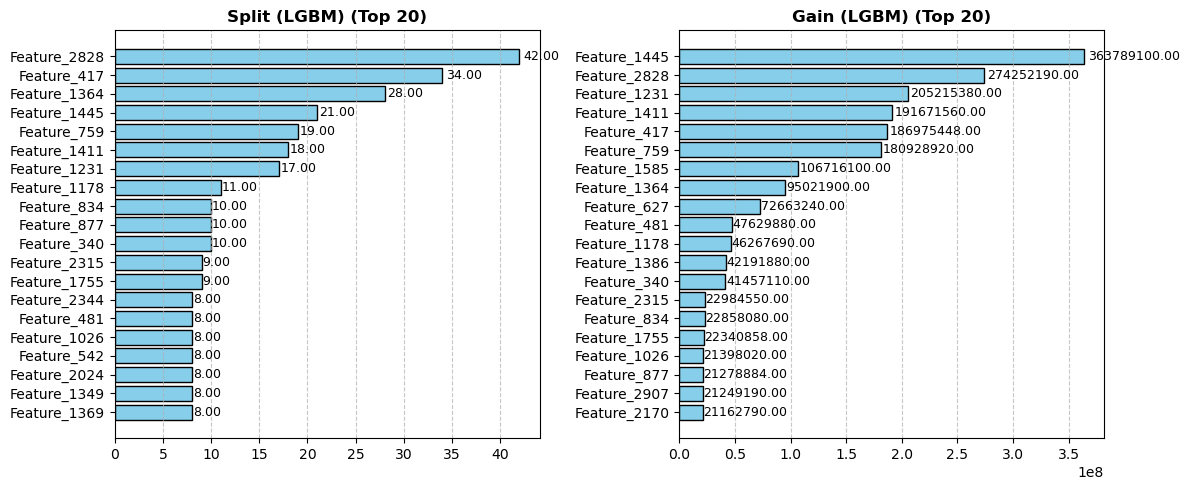

{'Split (LGBM)': {'Feature_2828': 42,
  'Feature_417': 34,
  'Feature_1364': 28,
  'Feature_1445': 21,
  'Feature_759': 19,
  'Feature_1411': 18,
  'Feature_1231': 17,
  'Feature_1178': 11,
  'Feature_834': 10,
  'Feature_877': 10,
  'Feature_340': 10,
  'Feature_2315': 9,
  'Feature_1755': 9,
  'Feature_481': 8,
  'Feature_1026': 8,
  'Feature_542': 8,
  'Feature_2024': 8,
  'Feature_1349': 8,
  'Feature_2344': 8,
  'Feature_1369': 8,
  'Feature_2428': 8,
  'Feature_1405': 8,
  'Feature_1388': 7,
  'Feature_2222': 7,
  'Feature_1991': 7,
  'Feature_1917': 7,
  'Feature_1554': 7,
  'Feature_2170': 7,
  'Feature_2332': 7,
  'Feature_2281': 7,
  'Feature_126': 7,
  'Feature_2065': 7,
  'Feature_2863': 7,
  'Feature_881': 7,
  'Feature_2890': 7,
  'Feature_1051': 7,
  'Feature_627': 7,
  'Feature_2907': 7,
  'Feature_854': 7,
  'Feature_2772': 7,
  'Feature_364': 7,
  'Feature_902': 7,
  'Feature_2930': 7,
  'Feature_1916': 6,
  'Feature_1680': 6,
  'Feature_1910': 6,
  'Feature_394': 6,


In [78]:

Importances = plot_model_importances(model, feature_names=feature_names, max_features=20)

Importances


In [ ]:
# Importances.keys()

C = 1.0 # Adjust this constant to be more or less strict in filtering features based on standard deviation

for imp_type, imp_values in Importances.items():
    # Filter features based on standard deviation
    significant_features = imp_values
    significant_features = {k: v for k, v in significant_features.items() if v > np.mean(list(significant_features.values())) +C*np.std(list(significant_features.values()))}

    print(f"Testing {imp_type}:")
    metrics = evaluate_feature_discovery(significant_features, true_linear_weights, true_interaction_weights)


Testing Split (LGBM):

           FEATURE DISCOVERY EVALUATION
Total True (Visible) Features: 32
  ├─ Purely Linear / Main:     3
  └─ Involved in Interactions: 29
Total Model Features Found:    368
--------------------------------------------------
True Positives (Correct): 16 -> ['Feature_2828', 'Feature_1386', 'Feature_1412', 'Feature_759', 'Feature_1585', 'Feature_1957', 'Feature_1411', 'Feature_627', 'Feature_1364', 'Feature_1178', 'Feature_417', 'Feature_1445', 'Feature_1231', 'Feature_481', 'Feature_2581', 'Feature_340']
False Positives (Noise):  352 -> ['Feature_838', 'Feature_126', 'Feature_2894', 'Feature_1653', 'Feature_275', 'Feature_717', 'Feature_2830', 'Feature_469', 'Feature_2805', 'Feature_48', 'Feature_655', 'Feature_2282', 'Feature_1388', 'Feature_244', 'Feature_2640', 'Feature_2407', 'Feature_2985', 'Feature_211', 'Feature_2823', 'Feature_347', 'Feature_1424', 'Feature_396', 'Feature_1908', 'Feature_1902', 'Feature_1115', 'Feature_512', 'Feature_2533', 'Feature_2116

In [87]:


# get a list of the union of the keys of true_linear_weights and true_interaction_weights
all_keys = set(true_linear_weights.keys()) | set(true_interaction_weights.keys())
all_keys

for imp_type, imp_values in Importances.items():
    print(f"Mean {imp_type} for true contributing features:", np.mean([imp_values.get(k, 0) for k in all_keys]))
    print(f"Mean {imp_type} for non-contributing features:", np.mean([imp_values.get(k, 0) for k in imp_values if k not in all_keys]))
    print(f"STD {imp_type} for all features:", np.std(list(imp_values.values())))

    # Get the importances for all keys
    importances_for_all_keys = {k: imp_values.get(k, 0) for k in all_keys}
    # Sort by importance
    sorted_importances = dict(sorted(importances_for_all_keys.items(), key=lambda item: item[1], reverse=True))
    print(f"{imp_type} for all contributing features (sorted):")
    print(sorted_importances)
    print("\n")
    print("----------------------------------------------------\n")





Mean Split (LGBM) for true contributing features: 7.1891891891891895
Mean Split (LGBM) for non-contributing features: 1.7435983827493262
STD Split (LGBM) for all features: 1.9723792457052696
Split (LGBM) for all contributing features (sorted):
{'Feature_2828': 42, 'Feature_417': 34, 'Feature_1364': 28, 'Feature_1445': 21, 'Feature_759': 19, 'Feature_1411': 18, 'Feature_1231': 17, 'Feature_1178': 11, 'Feature_340': 10, 'Feature_481': 8, 'Feature_627': 7, 'Feature_1585': 6, 'Feature_1386': 5, 'Feature_2581': 5, 'Feature_1412': 4, 'Feature_1957': 4, 'Feature_352': 3, 'Feature_1571': 3, 'Feature_612': 3, 'Feature_1350': 2, 'Feature_534': 2, 'Feature_2653': 2, 'Feature_2570': 2, 'Feature_209': 2, 'Feature_2250': 2, 'Feature_1034': 1, 'Feature_17': 1, 'Feature_183': 1, 'Feature_447': 1, 'Feature_2143': 1, 'Feature_2958': 1, 'Hidden_178': 0, 'Hidden_35': 0, 'Feature_498': 0, 'Hidden_52': 0, 'Hidden_153': 0, 'Hidden_8': 0}


----------------------------------------------------

Mean Gain (LGBM

### try to use SHAP to find the influencing inputs

In [80]:

# 5. Explainability (SHAP)
start_time = time.time()
shap_values = compute_shap_values(model, X_train, X_test)
end_time = time.time()
print(f"Execution time: {end_time - start_time} seconds")


Execution time: 3.668898582458496 seconds


#### individual SHAP features ranking

Plotting SHAP analysis for top 5 features: ['Feature_2828', 'Feature_417', 'Feature_1364', 'Feature_759', 'Feature_1445']


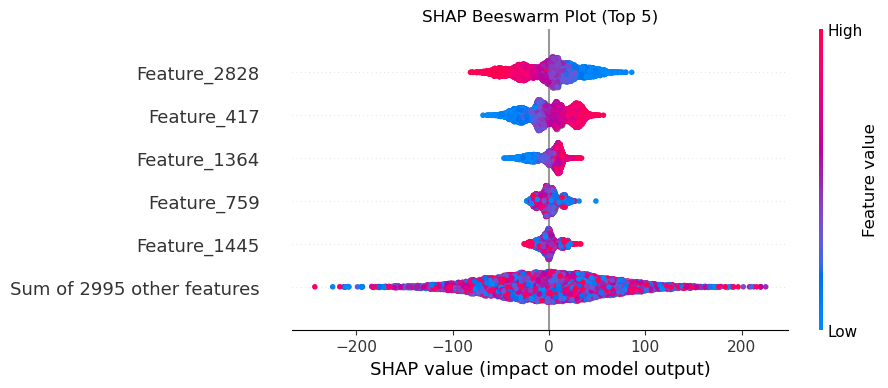

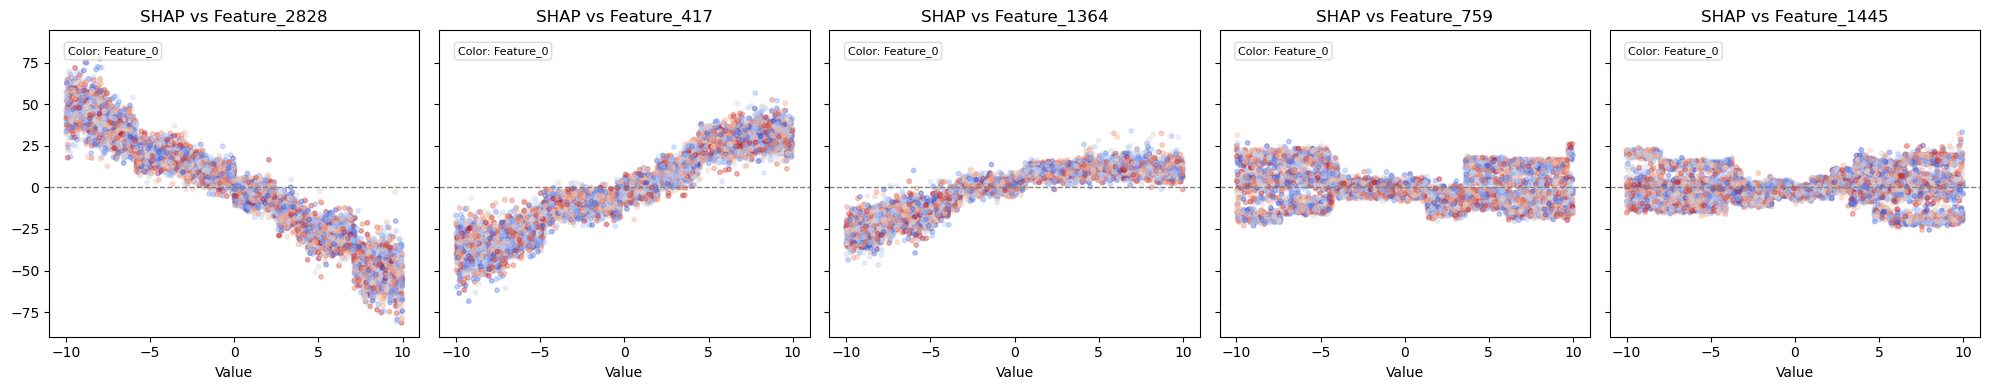

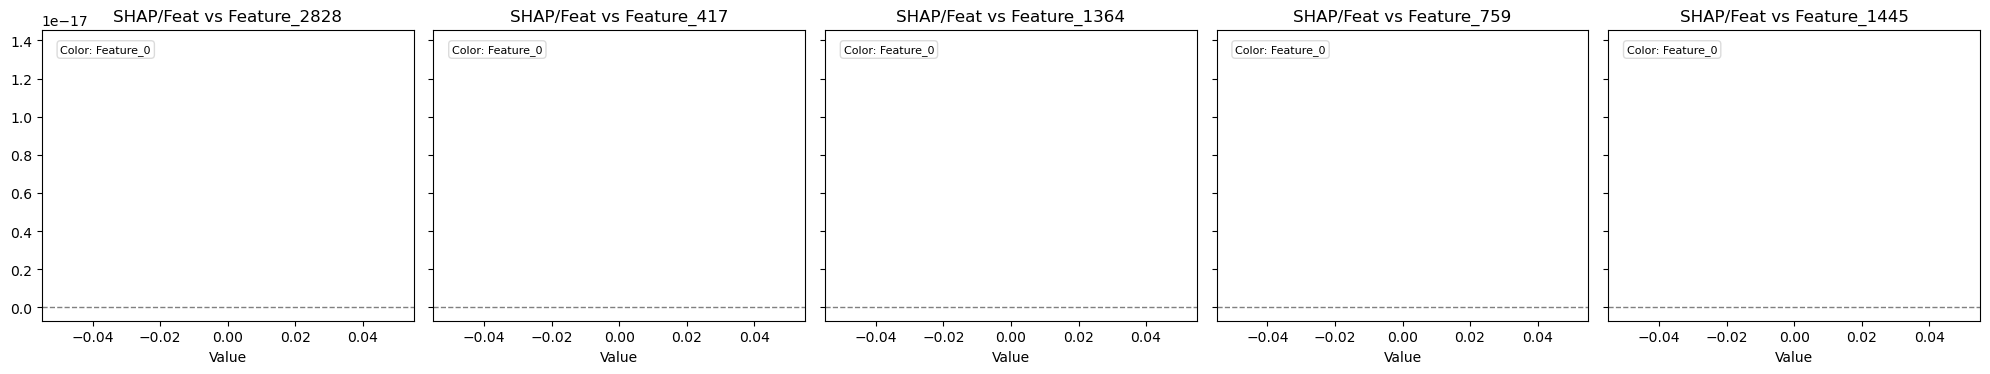

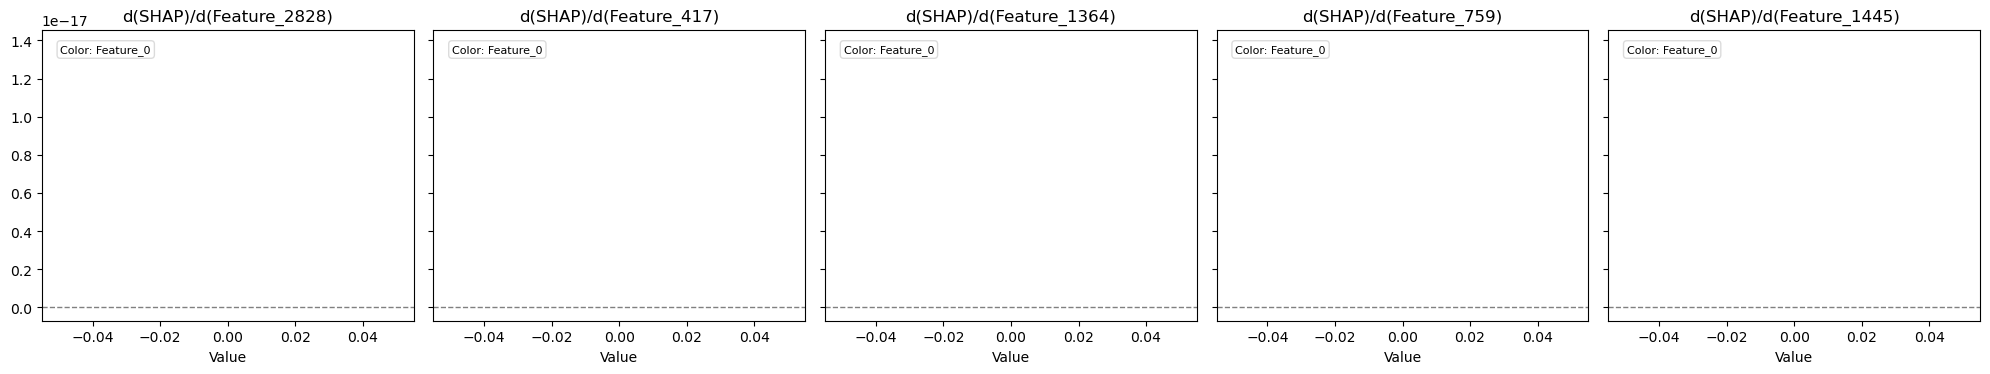

In [81]:

# 6. Visualization (SHAP)
plot_shap_analysis(shap_values, feature_names)


#### SHAP summry

In [82]:

# 8. Summary (SHAP)
ranked_features = print_feature_importance(shap_values)

print("Ranked Features by SHAP Importance:", ranked_features)



--- SHAP Feature Importance Ranking ---
SHAP Global Importance Dictionary:
  Feature_2828: 23.6361
  Feature_417: 19.1938
  Feature_1364: 10.5839
  Feature_759: 7.5723
  Feature_1445: 6.8731
  Feature_1411: 5.1624
  Feature_1231: 5.0188
  Feature_1026: 3.6935
  Feature_2315: 3.2719
  Feature_854: 2.9589
  Feature_2245: 2.7766
  Feature_816: 2.7407
  Feature_1369: 2.7141
  Feature_902: 2.5926
  Feature_1585: 2.5018
  Feature_1467: 2.4836
  Feature_877: 2.4334
  Feature_627: 2.4076
  Feature_2764: 2.4018
  Feature_1470: 2.3934
  Feature_1535: 2.3857
  Feature_2101: 2.3549
  Feature_481: 2.2890
  Feature_2067: 2.2338
  Feature_1386: 2.2114
  Feature_1088: 2.2047
  Feature_2907: 2.1397
  Feature_834: 2.1205
  Feature_956: 2.0972
  Feature_1987: 2.0838
  Feature_1388: 2.0768
  Feature_1392: 2.0540
  Feature_227: 2.0535
  Feature_1780: 2.0259
  Feature_1488: 2.0038
  Feature_403: 1.9790
  Feature_1755: 1.9708
  Feature_2222: 1.9155
  Feature_1324: 1.9129
  Feature_2170: 1.9109
  Feature_247

#### test SHAP Importances results

In [83]:
C = 1.0 # Adjust this constant to be more or less strict in filtering features based on standard deviation

significant_features = ranked_features
# get only values above the mean
significant_features = {k: v for k, v in significant_features.items() if v > np.mean(list(significant_features.values())) +C*np.std(list(significant_features.values()))}
significant_features 

print("Testing SHAP importance:")
metrics = evaluate_feature_discovery(significant_features, true_linear_weights, true_interaction_weights)



Testing SHAP importance:

           FEATURE DISCOVERY EVALUATION
Total True (Visible) Features: 32
  ├─ Purely Linear / Main:     3
  └─ Involved in Interactions: 29
Total Model Features Found:    138
--------------------------------------------------
True Positives (Correct): 11 -> ['Feature_2828', 'Feature_1386', 'Feature_759', 'Feature_1585', 'Feature_1411', 'Feature_627', 'Feature_1364', 'Feature_417', 'Feature_1445', 'Feature_1231', 'Feature_481']
False Positives (Noise):  127 -> ['Feature_1615', 'Feature_1590', 'Feature_469', 'Feature_1553', 'Feature_227', 'Feature_956', 'Feature_2282', 'Feature_1388', 'Feature_1963', 'Feature_2406', 'Feature_2823', 'Feature_2422', 'Feature_854', 'Feature_1102', 'Feature_1755', 'Feature_2024', 'Feature_1987', 'Feature_590', 'Feature_2310', 'Feature_1400', 'Feature_441', 'Feature_1780', 'Feature_1010', 'Feature_603', 'Feature_1722', 'Feature_894', 'Feature_1643', 'Feature_2664', 'Feature_2428', 'Feature_2790', 'Feature_1689', 'Feature_761', 'Feat

In [84]:


# get a list of the union of the keys of true_linear_weights and true_interaction_weights
all_keys = set(true_linear_weights.keys()) | set(true_interaction_weights.keys())
all_keys

print("Mean MODEL SHAP importance for true contributing features:", np.mean([ranked_features.get(k, 0) for k in all_keys]))
print("Mean MODEL SHAP importance for non-contributing features:", np.mean([ranked_features.get(k, 0) for k in ranked_features if k not in all_keys]))

print("STD MODEL SHAP importance for all features:", np.std([ranked_features.get(k, 0) for k in ranked_features]))

# Get the SHAP importances for all keys
shap_importances_for_all_keys = {k: ranked_features.get(k, 0) for k in all_keys}
# Sort by importance
sorted_shap_importances = dict(sorted(shap_importances_for_all_keys.items(), key=lambda item: item[1], reverse=True))
print("MODEL SHAP importance for all contributing features (sorted):")
sorted_shap_importances



Mean MODEL SHAP importance for true contributing features: 2.530951538624081
Mean MODEL SHAP importance for non-contributing features: 0.26610061875316227
STD MODEL SHAP importance for all features: 0.7255242882625732
MODEL SHAP importance for all contributing features (sorted):


{'Feature_2828': 23.63605961953187,
 'Feature_417': 19.193835482810243,
 'Feature_1364': 10.583902329050114,
 'Feature_759': 7.5723340490816335,
 'Feature_1445': 6.873128456949617,
 'Feature_1411': 5.162404645615418,
 'Feature_1231': 5.0188096939816615,
 'Feature_1585': 2.5018416797385115,
 'Feature_627': 2.4075739408277275,
 'Feature_481': 2.289031317613618,
 'Feature_1386': 2.2114320030519425,
 'Feature_340': 1.0085759139491088,
 'Feature_1178': 0.7827396545309637,
 'Feature_2581': 0.6841218938995204,
 'Feature_612': 0.6465437762811688,
 'Feature_1412': 0.5190121742557416,
 'Feature_1957': 0.45929210720675256,
 'Feature_1571': 0.4465976172793651,
 'Feature_209': 0.32980091801367073,
 'Feature_352': 0.21972547913759116,
 'Feature_2653': 0.21610449314441593,
 'Feature_534': 0.181758406673293,
 'Feature_1350': 0.17020599002038167,
 'Feature_2250': 0.10512952845271441,
 'Feature_183': 0.09664896249477355,
 'Feature_2570': 0.08581001706207167,
 'Feature_447': 0.06893299247031685,
 'Featur